<a href="https://colab.research.google.com/github/nafeessiddique-dev/XAIApproxRL/blob/main/MD_mirai_apx_homogeneous_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch-xla
!pip install numpy torchao
!pip install ninja

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 8.8 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Running on CPU
Simulating 11 processing cores (one per multiplier configuration)

FFT-BASED FEATURE ATTRIBUTION — MIRAI BOTNET DETECTION
AdaPT Offline/Online Pipeline with EvoApprox Multipliers
RL (SoftmaxBandit) selects multipliers in the Offline Phase

  [C++ kernels] missing headers: ['mul8s_1KV6', 'mul8s_1KV8', 'mul8s_1KV9', 'mul8s_1KVA', 'mul8s_1KVP', 'mul8s_1KVQ', 'mul8s_1KX5', 'mul8s_1L2J', 'mul8s_1L2L', 'mul8s_1L2N', 'mul8s_1L12'] — using Python MRE simulation

LOADING STANDALONE CHECKPOINT
  Checkpoint keys: ['input_proj.0.weight', 'input_proj.0.bias', 'input_proj.1.weight', 'input_proj.1.bias', 'input_proj.1.running_mean', 'input_proj.1.running_var', 'input_proj.1.num_batches_tracked', 'input_proj.3.weight', 'input_proj.3.bias', 'input_proj.4.weight', 'input_proj.4.bias', 'input_proj.4.running_mean', 'input_proj.4.running_var', 'input_proj.4.num_batches_tracked', 'input_proj.6.weight', 'input_proj.6.bias', 'resnet.conv1.weight', 'resnet.bn1.weight', 'resnet.bn1.bias', 'resnet

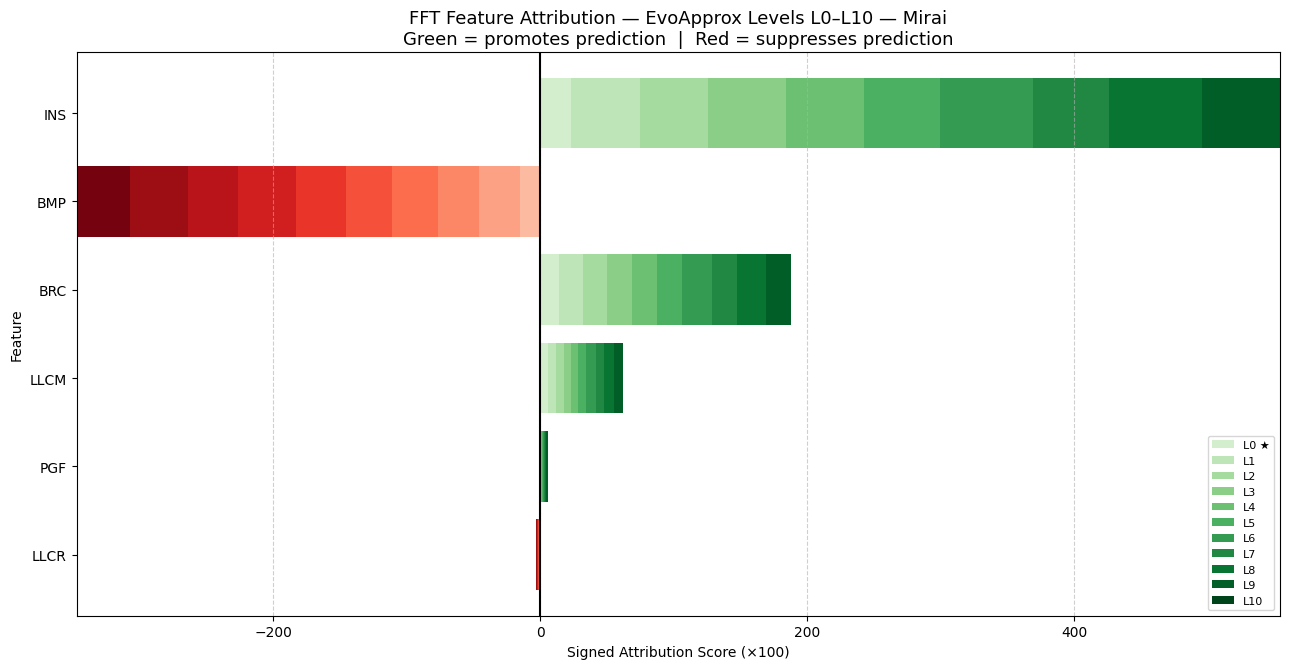

Saved: combined_waterfall_plot_mirai.png


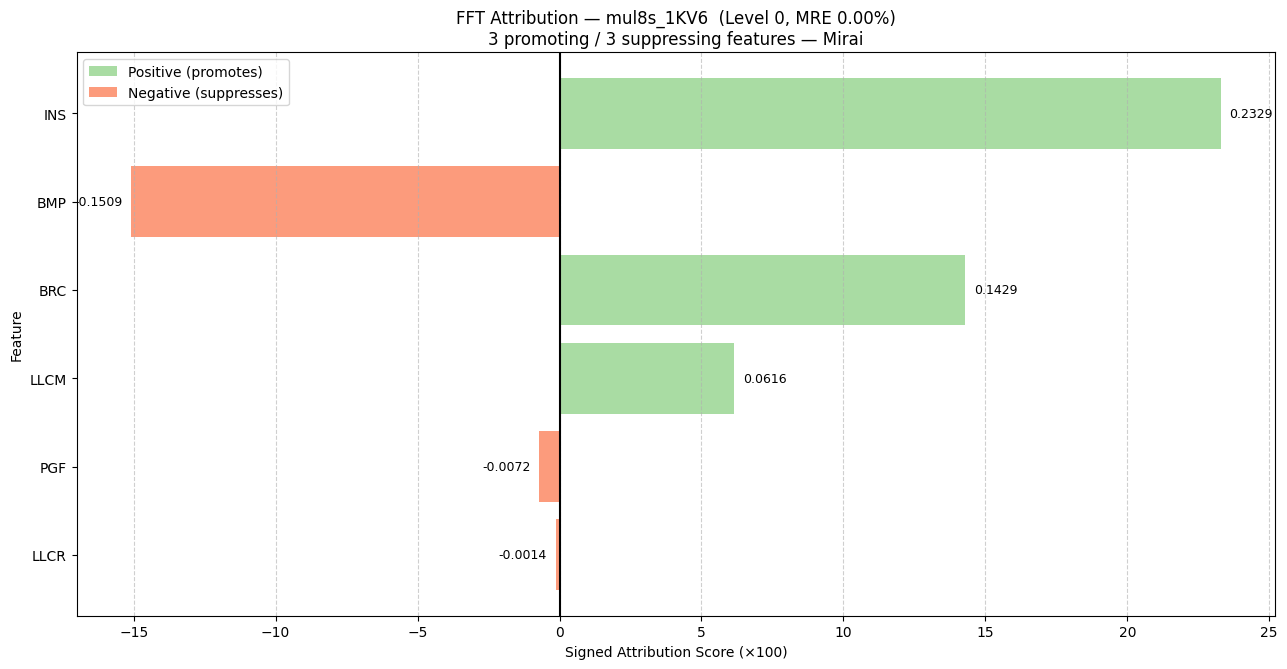

Saved: waterfall_mirai_mul8s_1KV6_L0.png


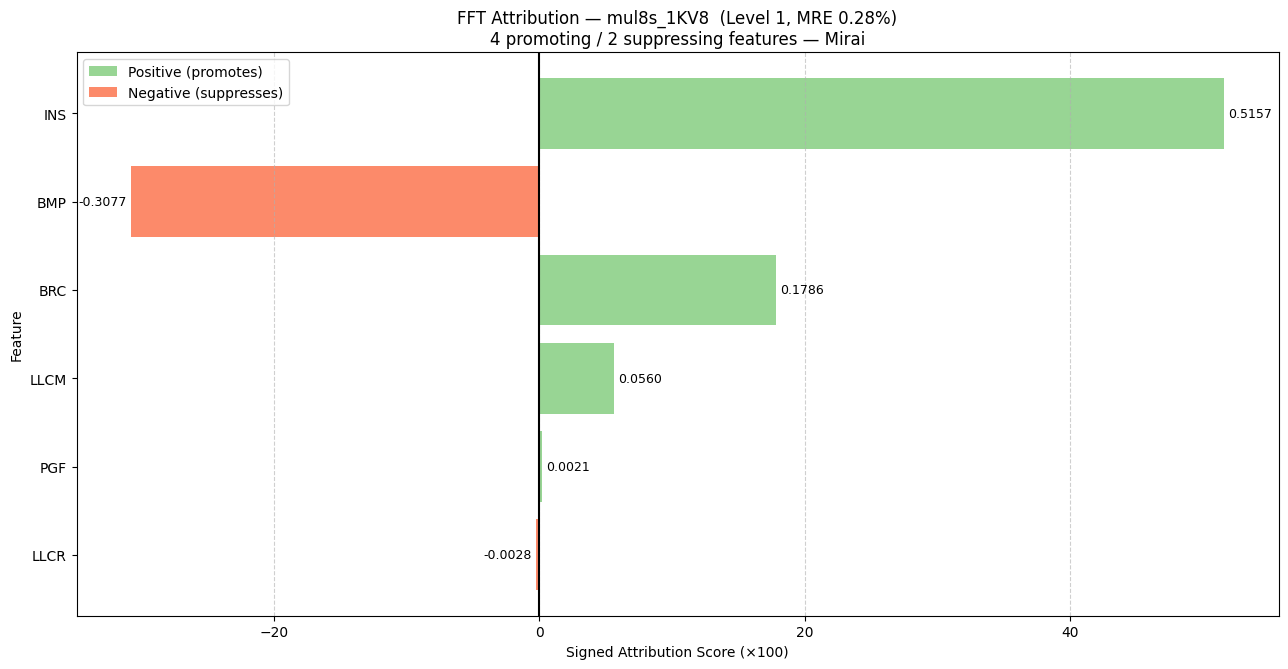

Saved: waterfall_mirai_mul8s_1KV8_L1.png


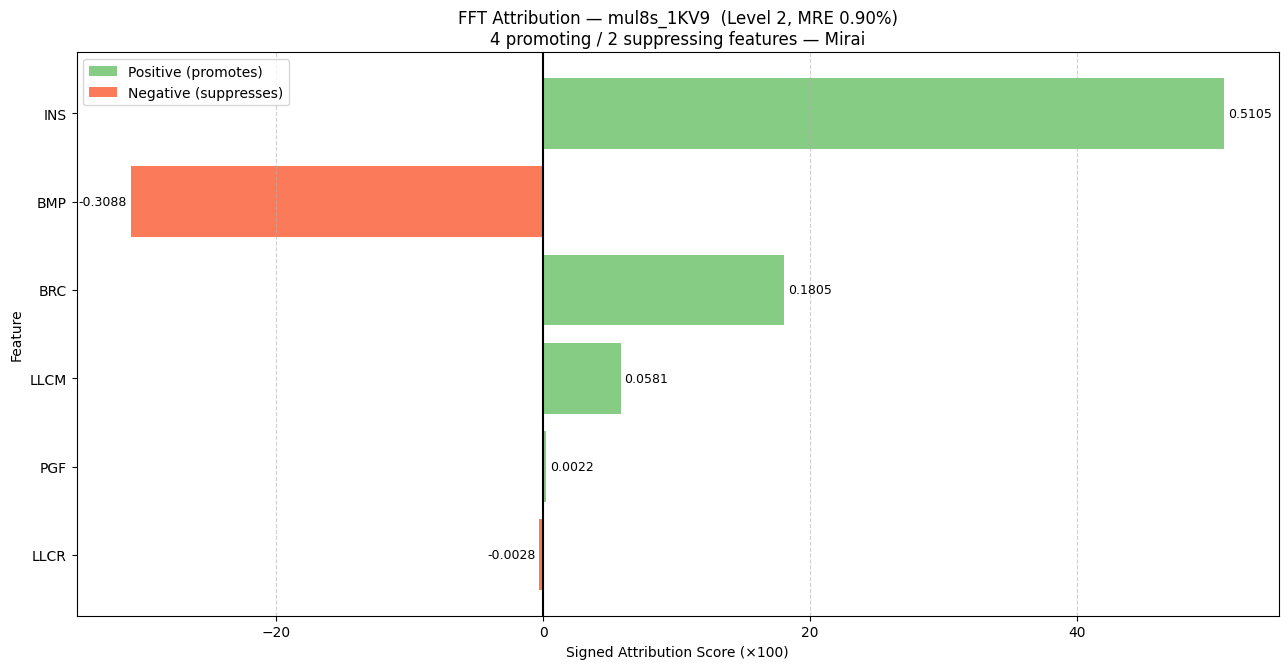

Saved: waterfall_mirai_mul8s_1KV9_L2.png


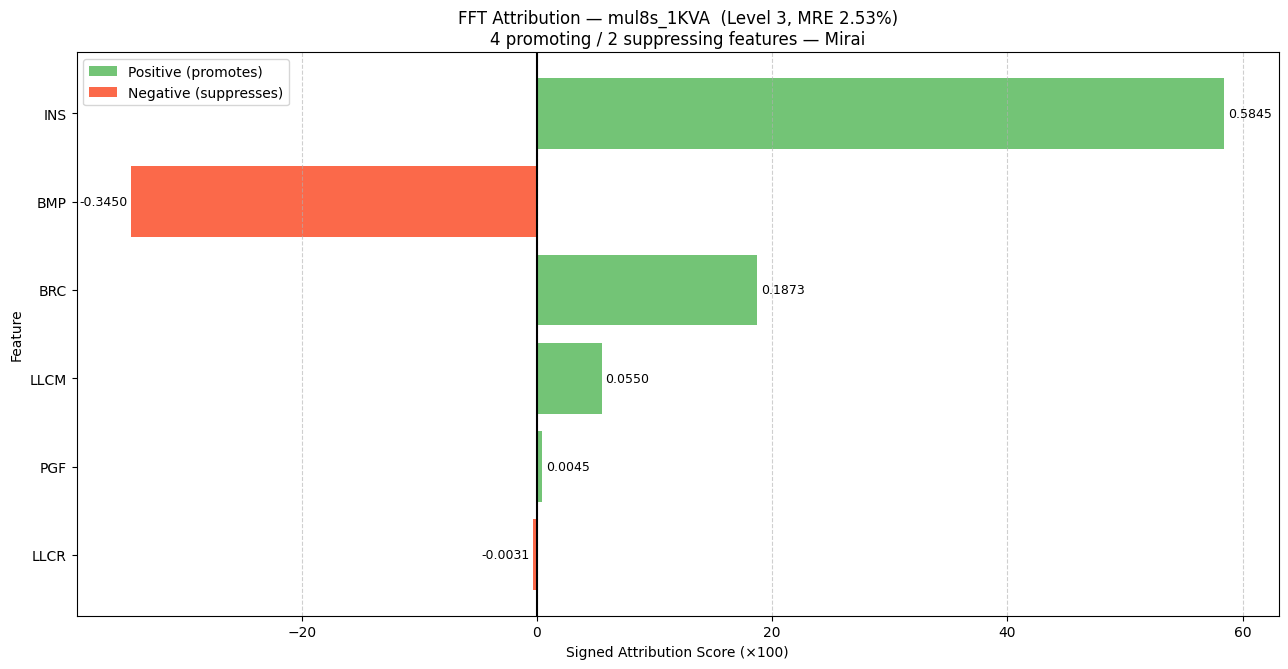

Saved: waterfall_mirai_mul8s_1KVA_L3.png


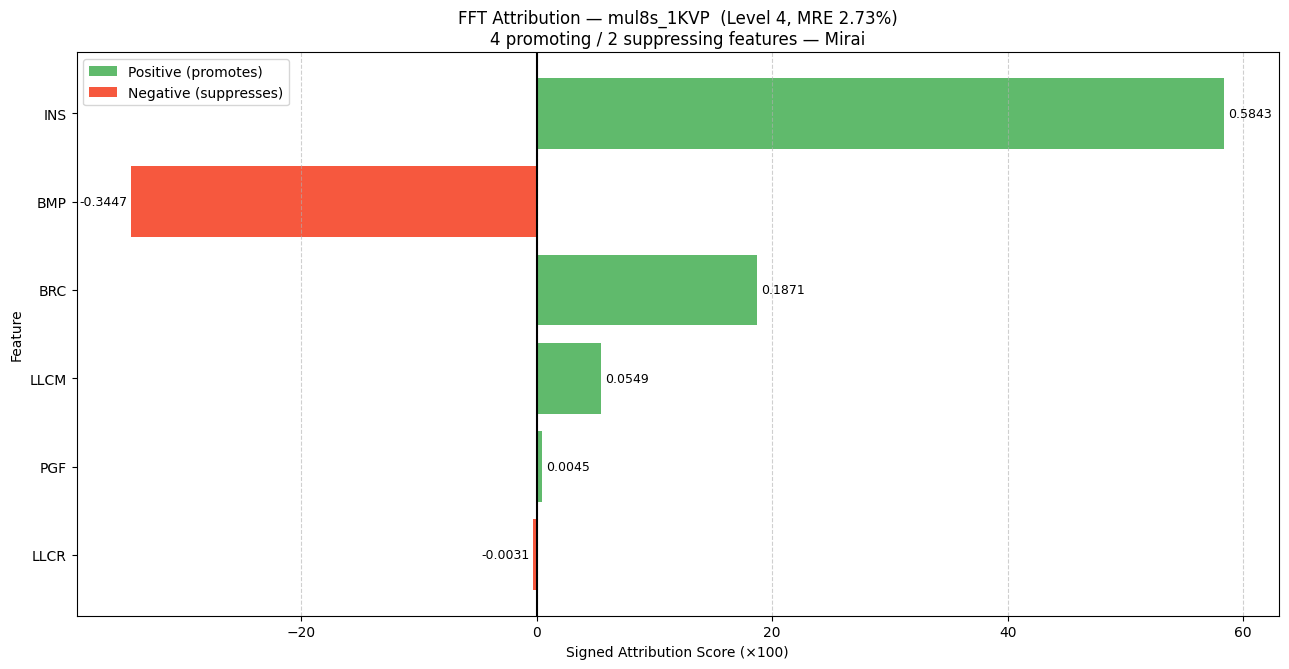

Saved: waterfall_mirai_mul8s_1KVP_L4.png


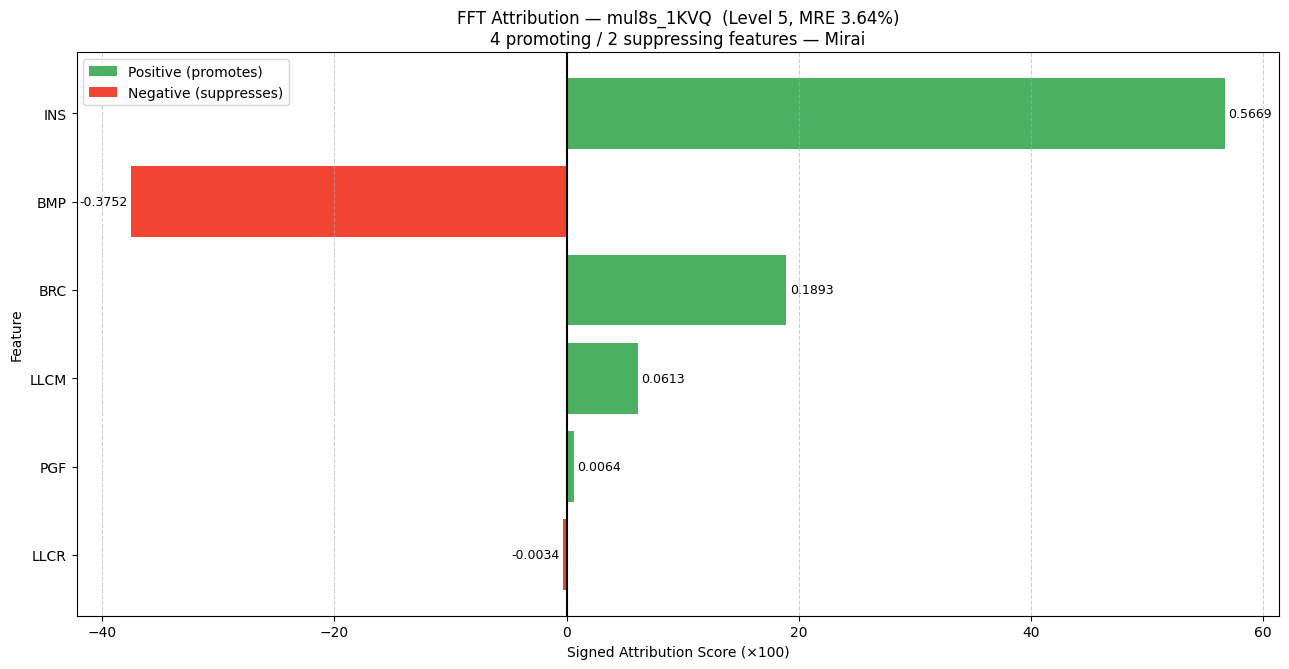

Saved: waterfall_mirai_mul8s_1KVQ_L5.png


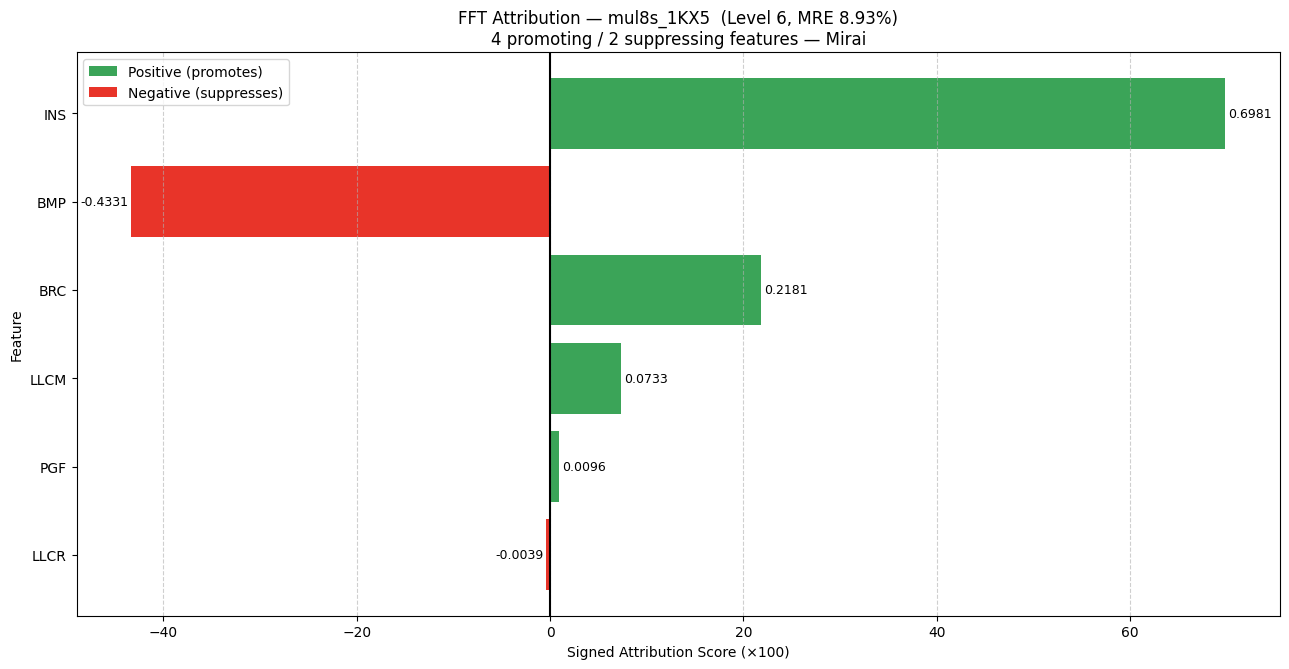

Saved: waterfall_mirai_mul8s_1KX5_L6.png


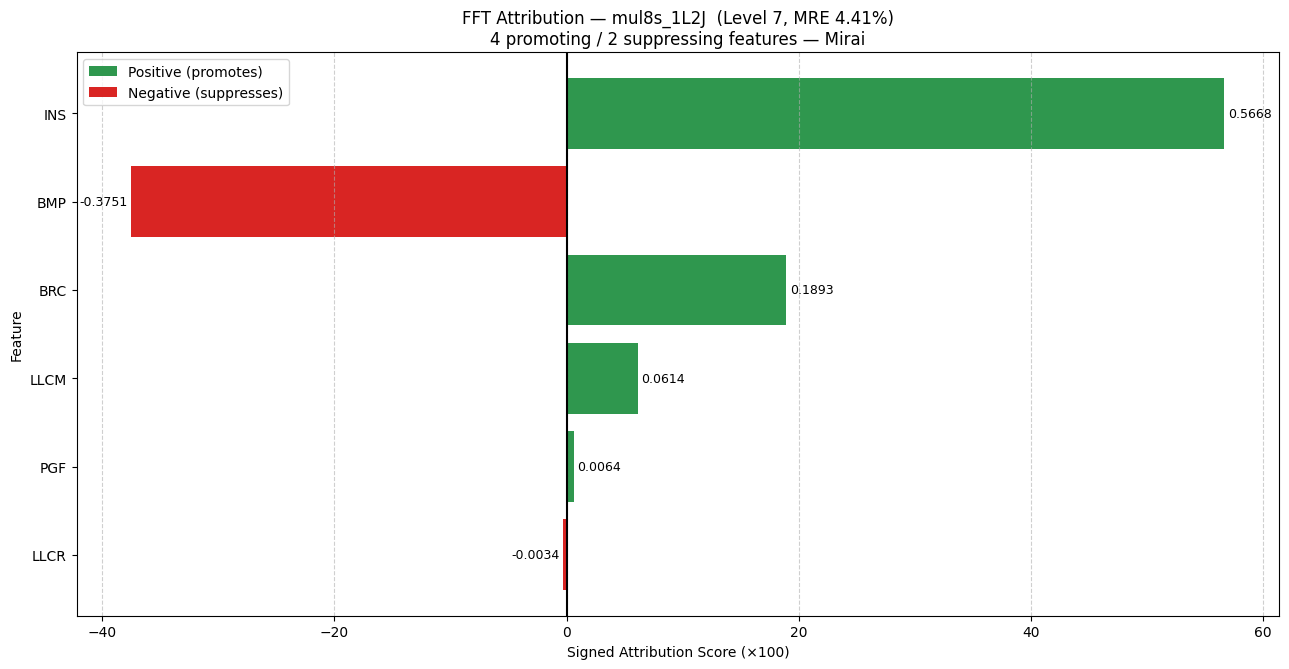

Saved: waterfall_mirai_mul8s_1L2J_L7.png


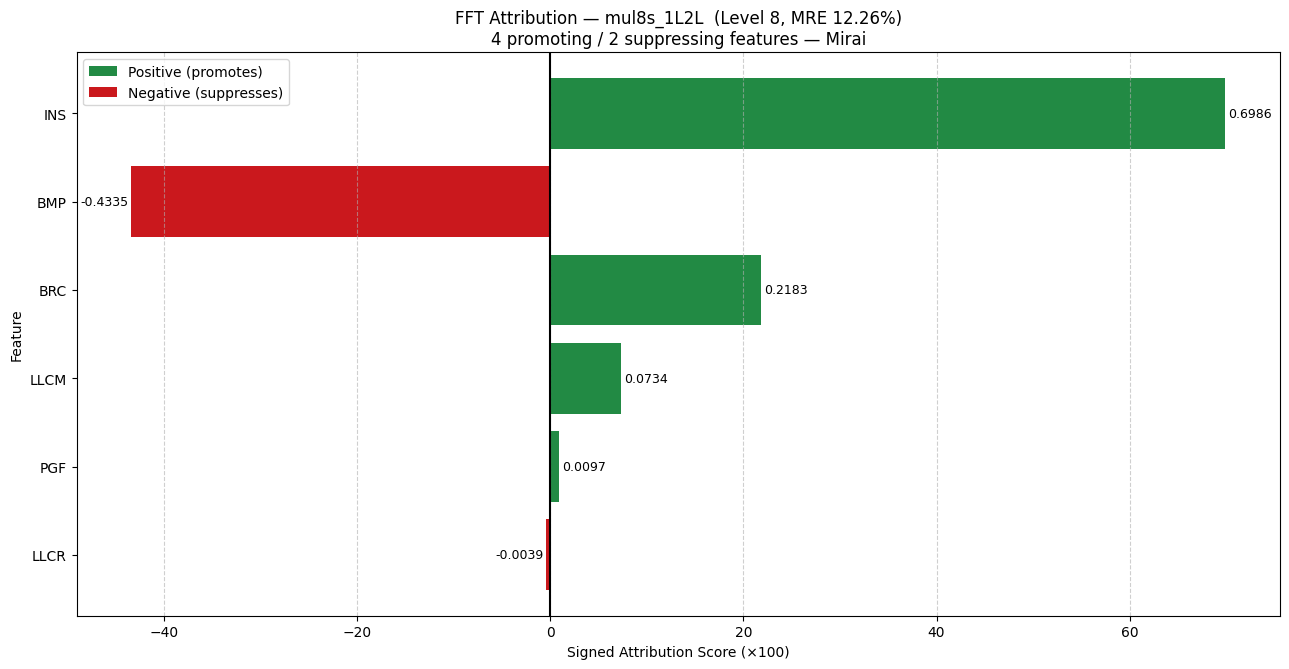

Saved: waterfall_mirai_mul8s_1L2L_L8.png


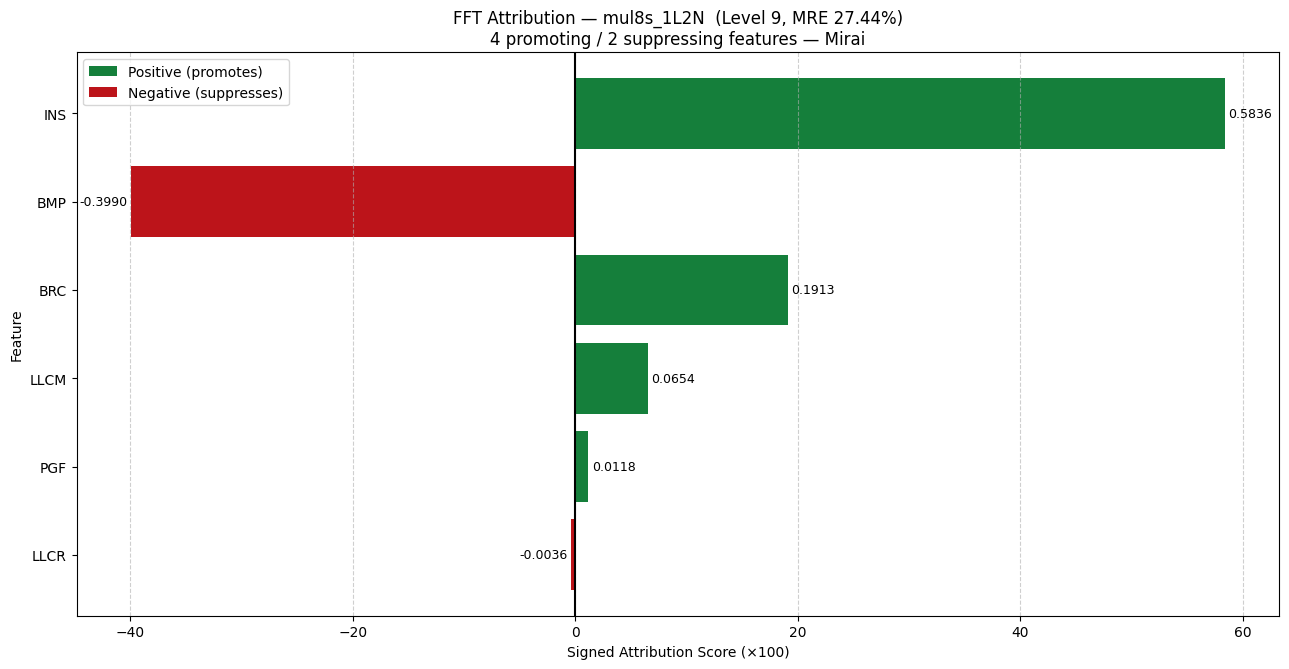

Saved: waterfall_mirai_mul8s_1L2N_L9.png


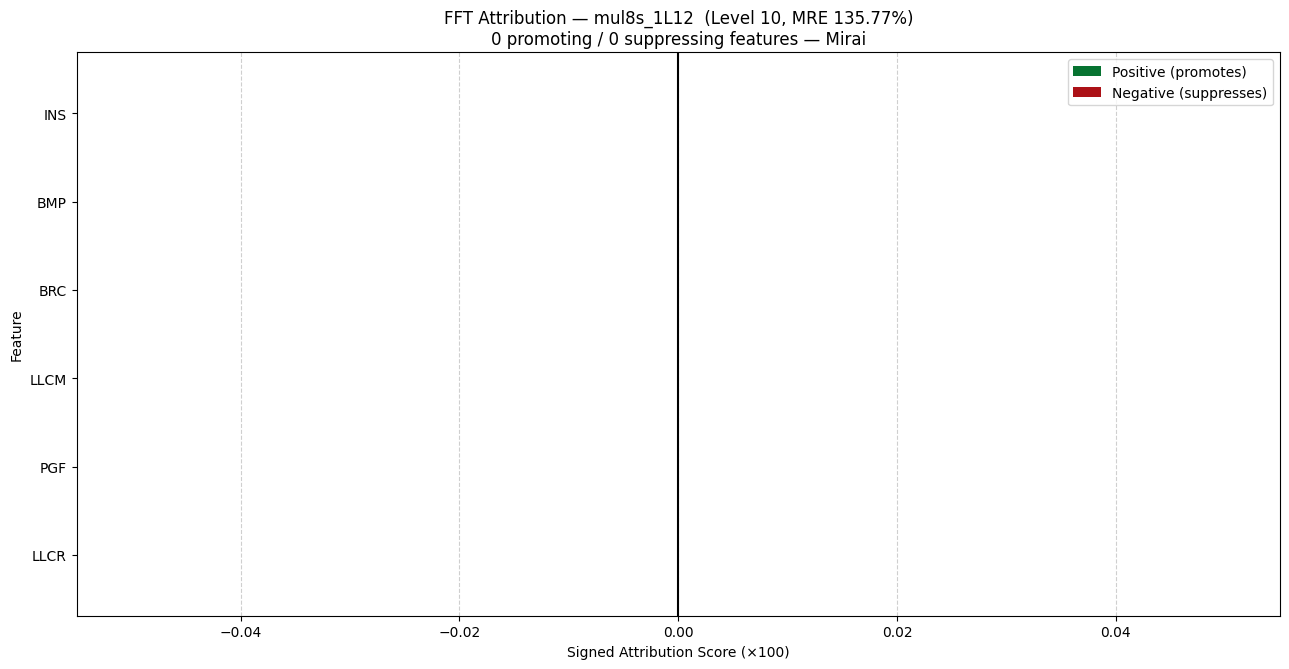

Saved: waterfall_mirai_mul8s_1L12_L10.png

=== Combo Waterfall Plot (3-Multiplier Route) ===


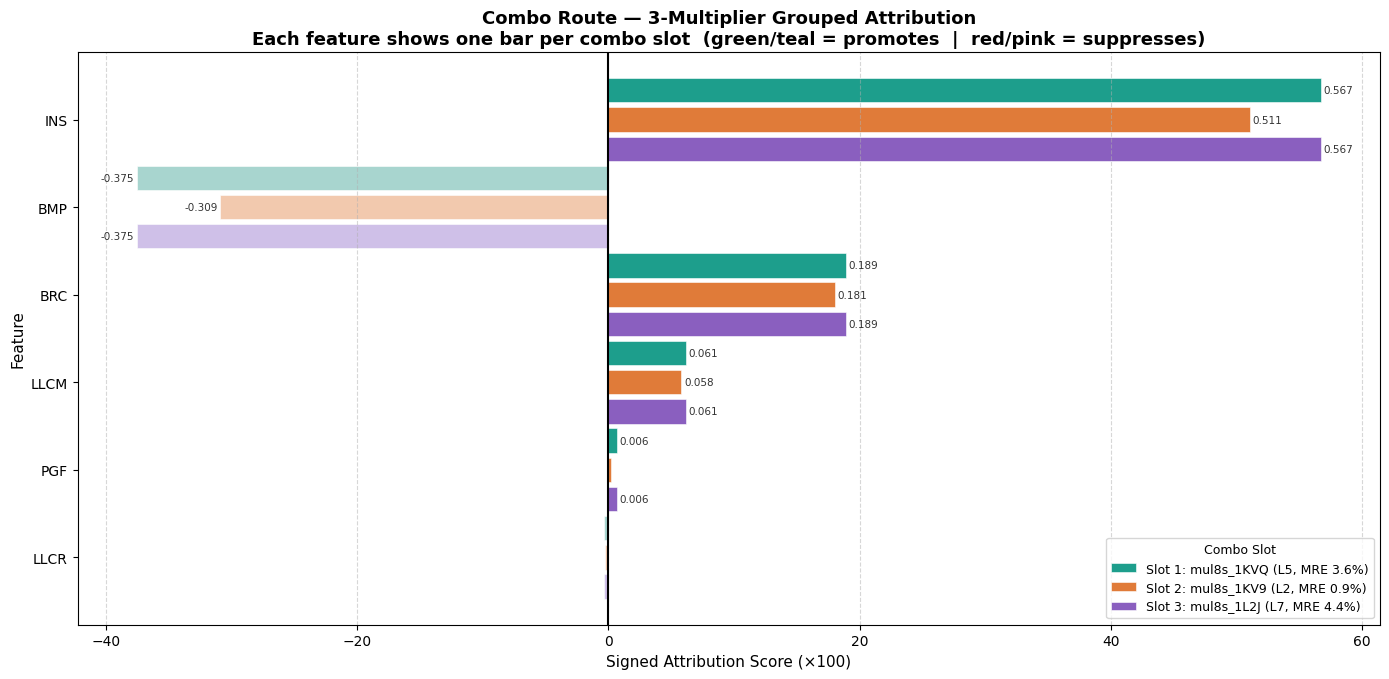

Saved: combo_waterfall_mirai.png


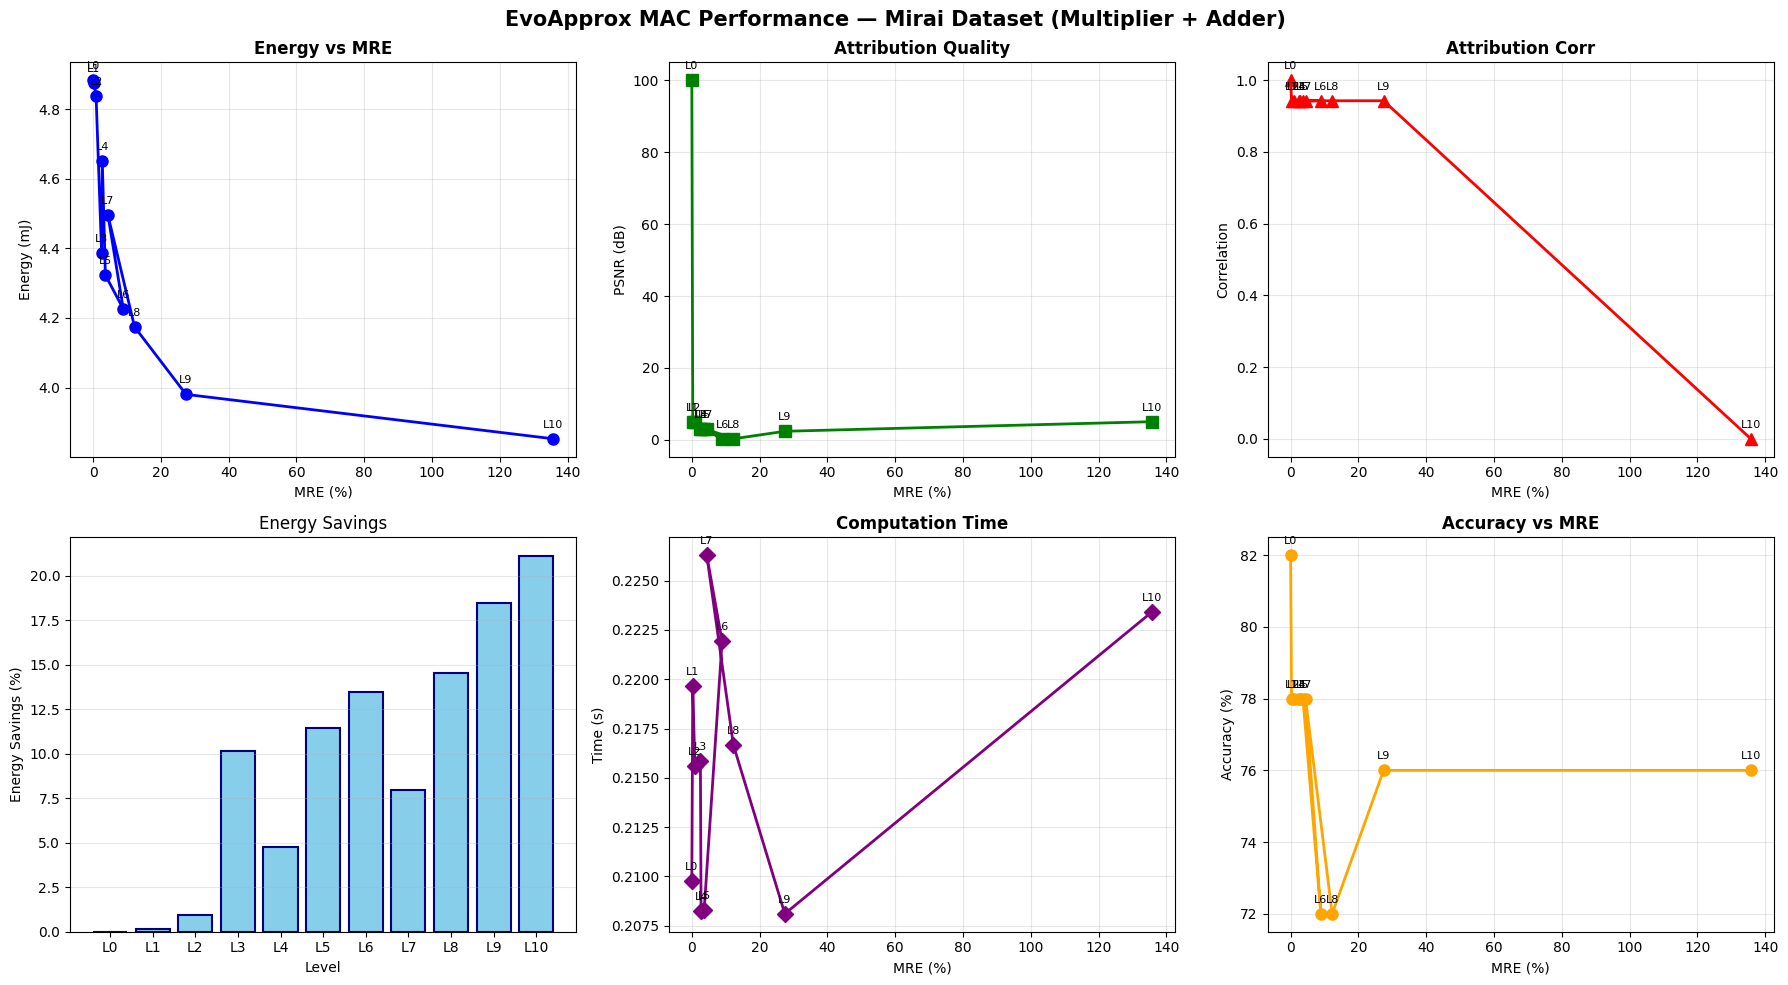

Saved: evoapprox_metrics_mirai.png


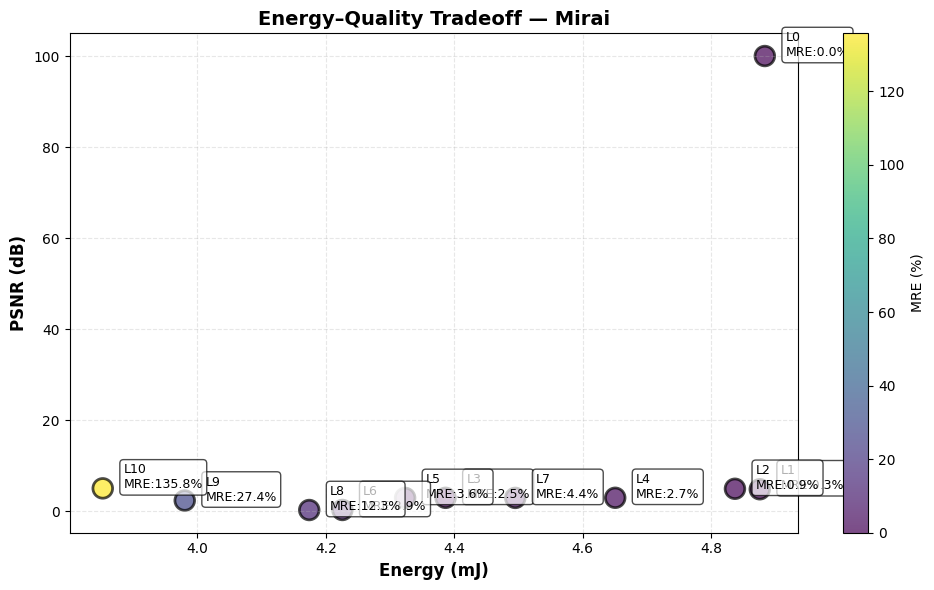

Saved: energy_quality_tradeoff_mirai.png

✅ Pipeline complete.
   Global RL best  : mul8s_1KV6_add16se_2TN
   Online clusters : {0: ['mul8s_1KVQ_add16se_2TN', 'mul8s_1KV9_add16se_2TN', 'mul8s_1L2J_add16se_2TN'], 1: ['mul8s_1KVQ_add16se_2TN', 'mul8s_1KVA_add16se_2TN', 'mul8s_1L2J_add16se_2TN'], 2: ['mul8s_1L2N_add16se_2TN', 'mul8s_1KVA_add16se_2TN', 'mul8s_1KVQ_add16se_2TN']}


In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
from scipy.stats import spearmanr, pearsonr
import gc
import math
import time

from torch import nn, manual_seed, no_grad, from_numpy
import torch.nn.functional as F
import torchvision.models as models
import torch as pt

warnings.filterwarnings('ignore')
np.random.seed(42)
manual_seed(42)

# =============================================================================
# CONFIGURATION
# =============================================================================
CPP_KERNEL_SOURCE_DIR = '/content/drive/MyDrive/adapt-main/adapt/cpu-kernels'
MODEL_PATH = 'mirai_resnet50_baseline.pth'
DATASET_PATH = 'synthetic_mirai_hpc_50k.csv'
USE_CPP_KERNEL = True
K_CLUSTERS = 3           # Number of clusters for offline K-Means  (was 5)
PCA_DIM = 16             # PCA target dimension for penultimate features  (was 128)
SAMPLES_PER_CLUSTER = 2  # Representative samples per cluster for RL evaluation  (was 5)
TRAIN_SUBSAMPLE = 2000   # Max training rows used for clustering/PCA  (was full 50k)

# =============================================================================
# MAC CONFIGURATIONS (Multiplier + Adder pairs — add16se_2TN adder throughout)
# =============================================================================
MAC_CONFIGURATIONS = {
    'mul8s_1KV6_add16se_2TN': {'multiplier': 'mul8s_1KV6', 'adder': 'add16se_2TN', 'mul_power_mW': 0.425, 'mul_delay_ns': 1.48, 'add_power_mW': 0.072, 'add_delay_ns': 0.50, 'mae': 0.00,   'mre': 0.00,   'level': 0},
    'mul8s_1KV8_add16se_2TN': {'multiplier': 'mul8s_1KV8', 'adder': 'add16se_2TN', 'mul_power_mW': 0.422, 'mul_delay_ns': 1.48, 'add_power_mW': 0.072, 'add_delay_ns': 0.50, 'mae': 0.0018, 'mre': 0.28,   'level': 1},
    'mul8s_1KV9_add16se_2TN': {'multiplier': 'mul8s_1KV9', 'adder': 'add16se_2TN', 'mul_power_mW': 0.410, 'mul_delay_ns': 1.47, 'add_power_mW': 0.072, 'add_delay_ns': 0.50, 'mae': 0.0064, 'mre': 0.90,   'level': 2},
    'mul8s_1KVA_add16se_2TN': {'multiplier': 'mul8s_1KVA', 'adder': 'add16se_2TN', 'mul_power_mW': 0.391, 'mul_delay_ns': 0.89, 'add_power_mW': 0.072, 'add_delay_ns': 0.50, 'mae': 0.019,  'mre': 2.53,   'level': 3},
    'mul8s_1KVP_add16se_2TN': {'multiplier': 'mul8s_1KVP', 'adder': 'add16se_2TN', 'mul_power_mW': 0.363, 'mul_delay_ns': 1.37, 'add_power_mW': 0.072, 'add_delay_ns': 0.50, 'mae': 0.051,  'mre': 2.73,   'level': 4},
    'mul8s_1KVQ_add16se_2TN': {'multiplier': 'mul8s_1KVQ', 'adder': 'add16se_2TN', 'mul_power_mW': 0.351, 'mul_delay_ns': 0.89, 'add_power_mW': 0.072, 'add_delay_ns': 0.50, 'mae': 0.056,  'mre': 3.64,   'level': 5},
    'mul8s_1KX5_add16se_2TN': {'multiplier': 'mul8s_1KX5', 'adder': 'add16se_2TN', 'mul_power_mW': 0.289, 'mul_delay_ns': 0.89, 'add_power_mW': 0.072, 'add_delay_ns': 0.50, 'mae': 0.15,   'mre': 8.93,   'level': 6},
    'mul8s_1L2J_add16se_2TN': {'multiplier': 'mul8s_1L2J', 'adder': 'add16se_2TN', 'mul_power_mW': 0.301, 'mul_delay_ns': 1.36, 'add_power_mW': 0.072, 'add_delay_ns': 0.50, 'mae': 0.081,  'mre': 4.41,   'level': 7},
    'mul8s_1L2L_add16se_2TN': {'multiplier': 'mul8s_1L2L', 'adder': 'add16se_2TN', 'mul_power_mW': 0.200, 'mul_delay_ns': 1.14, 'add_power_mW': 0.072, 'add_delay_ns': 0.50, 'mae': 0.23,   'mre': 12.26,  'level': 8},
    'mul8s_1L2N_add16se_2TN': {'multiplier': 'mul8s_1L2N', 'adder': 'add16se_2TN', 'mul_power_mW': 0.126, 'mul_delay_ns': 0.94, 'add_power_mW': 0.072, 'add_delay_ns': 0.50, 'mae': 0.52,   'mre': 27.44,  'level': 9},
    'mul8s_1L12_add16se_2TN': {'multiplier': 'mul8s_1L12', 'adder': 'add16se_2TN', 'mul_power_mW': 0.052, 'mul_delay_ns': 0.89, 'add_power_mW': 0.072, 'add_delay_ns': 0.50, 'mae': 3.08,   'mre': 135.77, 'level': 10},
}

# =============================================================================
# DEVICE DETECTION  (PyTorch only — no TensorFlow)
# =============================================================================
if pt.cuda.is_available():
    device_type = "GPU"
    print("Running on GPU")
elif pt.backends.mps.is_available():
    device_type = "MPS"
    print("Running on Apple MPS")
else:
    device_type = "CPU"
    print("Running on CPU")

# Number of "cores" = number of distinct multiplier configurations available
N_CORES = len(MAC_CONFIGURATIONS)
print(f"Simulating {N_CORES} processing cores (one per multiplier configuration)")

# =============================================================================
# HARDWARE CONFIG & RL REWARD WEIGHTS
# =============================================================================
HARDWARE_CONFIG = {
    'clock_period_ns':           3.0,
    'pe_array_size':             65536,
    'load_weights_cycles':       100,
    'sram_energy_pJ_per_access': 1.92,
}

RL_REWARD_WEIGHTS = {
    'energy_efficiency': 0.40,
    'fft_correlation':   0.35,   # Spearman corr between accurate/approx attributions
    'fft_psnr':          0.25,   # PSNR between accurate/approx attributions
}

# =============================================================================
# LAYER DESCRIPTOR & PROFILER  (RoHNAS analytical model)
# =============================================================================
class LayerDescriptor:
    def __init__(self, layer_type, name, input_shape, output_shape,
                 kernel_size=1, stride=1, params=None):
        self.layer_type   = layer_type
        self.name         = name
        self.input_shape  = input_shape
        self.output_shape = output_shape
        self.kernel_size  = kernel_size
        self.stride       = stride
        self.params       = params or {}
        if layer_type == 'conv':
            self.chin, self.hin, self.win    = input_shape
            self.chout, self.hout, self.wout = output_shape
            self.nin = self.hin; self.nout = self.hout
            self.capsin = self.capsout = 0
        elif layer_type == 'fc':
            self.chin  = input_shape[0]  if isinstance(input_shape,  tuple) else input_shape
            self.chout = output_shape[0] if isinstance(output_shape, tuple) else output_shape
            self.nin = self.nout = 1
            self.hin = self.win = self.hout = self.wout = 1
            self.capsin = self.capsout = 0

    def get_weights_count(self):
        if self.layer_type == 'conv':  return self.kernel_size**2 * self.chin * self.chout
        elif self.layer_type == 'fc':  return self.chin * self.chout
        return 0

    def get_sum_count(self):
        if self.layer_type == 'conv':  return self.kernel_size**2 * self.chin
        elif self.layer_type == 'fc':  return self.chin
        return 0

    def get_feature_maps_count(self):
        return self.nout * self.nout if self.layer_type == 'conv' else 1


class LayerProfiler:
    def __init__(self, model, input_shape=(1, 6)):
        self.model = model; self.input_shape = input_shape
        self.layer_descriptors = []; self.hooks = []

    def _register_hooks(self):
        def hook_fn(name, lt):
            def hook(module, inp, out):
                i = inp[0] if isinstance(inp, tuple) else inp
                if isinstance(module, nn.Conv2d):
                    ks = module.kernel_size[0] if isinstance(module.kernel_size, tuple) else module.kernel_size
                    st = module.stride[0]      if isinstance(module.stride,      tuple) else module.stride
                    self.layer_descriptors.append(LayerDescriptor(
                        'conv', name, tuple(i.shape[1:]), tuple(out.shape[1:]), ks, st))
                elif isinstance(module, nn.Linear):
                    is_ = (i.shape[1],) if len(i.shape[1:]) == 1 else (int(np.prod(i.shape[1:])),)
                    self.layer_descriptors.append(LayerDescriptor('fc', name, is_, (out.shape[1],)))
            return hook
        for name, mod in self.model.named_modules():
            if isinstance(mod, (nn.Conv2d, nn.Linear)):
                self.hooks.append(mod.register_forward_hook(
                    hook_fn(name, 'conv' if isinstance(mod, nn.Conv2d) else 'fc')))

    def profile(self):
        self._register_hooks()
        self.model.eval()
        with pt.no_grad():
            _ = self.model(pt.randn(*self.input_shape))
        for h in self.hooks: h.remove()
        return self.layer_descriptors


# =============================================================================
# ROHNAS ENERGY MODEL  (replaces simple calculate_mac_energy)
# =============================================================================
class RoHNASEnergyModel:
    """
    Analytical energy model derived from the RoHNAS framework.
    Accounts for PE-array tiling, SRAM access energy, and per-MAC energy
    computed from the selected multiplier+adder pair power/delay specs.
    Used for FFT attribution energy estimation by treating attribution
    forward passes as the computation workload.
    """
    def __init__(self, mac_config_name: str):
        cfg = MAC_CONFIGURATIONS[mac_config_name]
        self.config_name         = mac_config_name
        self.approximation_level = cfg['level']
        self.mre                 = cfg['mre']
        # Per-MAC energy = (mul_power × mul_delay) + (add_power × add_delay)  [pJ]
        self.mac_energy_pJ = (cfg['mul_power_mW'] * cfg['mul_delay_ns'] +
                              cfg['add_power_mW'] * cfg['add_delay_ns'])
        self.T          = HARDWARE_CONFIG['clock_period_ns']
        self.pe_array_size = HARDWARE_CONFIG['pe_array_size']
        self.E_sram     = HARDWARE_CONFIG['sram_energy_pJ_per_access']

    def calculate_layer_energy(self, ld: LayerDescriptor):
        """RoHNAS per-layer latency (ns) and energy (pJ)."""
        wl = ld.get_weights_count()
        sl = ld.get_sum_count()
        fl = ld.get_feature_maps_count()
        wPE   = math.ceil(wl / (self.pe_array_size * min(self.pe_array_size, sl)))
        m_acc = 65536 if fl == 1 else self.pe_array_size * max(sl - 15, 1)
        cl    = wl * wPE + fl
        latency_ns = cl * self.T
        energy_pJ  = (m_acc / 128.0) * self.E_sram + cl * self.mac_energy_pJ
        return latency_ns, energy_pJ

    def calculate_model_energy(self, layer_descs):
        """Sum latency and energy across all profiled layers."""
        total_lat = total_en = 0.0
        for ld in layer_descs:
            l, e = self.calculate_layer_energy(ld)
            total_lat += l; total_en += e
        return total_lat, total_en

    def calculate_fft_energy(self, n_features: int, grid_size: int,
                              layer_descs: list):
        """
        Estimate energy for one FFT attribution pass.

        The FFT attribution computes:
          - 2 FFT/IFFT forward passes per feature block (original + perturbed)
          - grid_size blocks total
        So total forward passes ≈ n_features * grid_size * 2,
        mirroring the SHAP coalition-sample interpretation from the SHAP code.

        Returns:
            total_energy_mJ : float
            breakdown       : dict
        """
        forward_passes = n_features * grid_size * 2
        _, single_pJ   = self.calculate_model_energy(layer_descs)
        total_pJ       = single_pJ * forward_passes
        total_mJ       = total_pJ / 1e9
        breakdown = {
            'forward_passes':     forward_passes,
            'single_inference_pJ': single_pJ,
            'total_energy_pJ':    total_pJ,
            'config_name':        self.config_name,
            'approximation_level': self.approximation_level,
            'mac_energy_pJ':      self.mac_energy_pJ,
            'total':              total_mJ,
        }
        return total_mJ, breakdown

# =============================================================================
# APPROXIMATE LINEAR LAYER (AdaPT-style)
# =============================================================================
class AdaPT_Linear_MRE_Function(pt.autograd.Function):
    @staticmethod
    def forward(ctx, inp, w, b, bias_flag, mre):
        ctx.save_for_backward(inp, w, b)
        ctx.bias_flag = bias_flag
        ctx.mre = mre

        if mre < 0.01:
            out = pt.matmul(inp, w.t())
        else:
            qi = pt.clamp(inp * 127.0, -128, 127).to(pt.int8)
            qw = pt.clamp(w * 127.0, -128, 127).to(pt.int8)
            shift = 1 if mre < 1.0 else (2 if mre < 5.0 else (3 if mre < 15.0 else 4))
            qi = (qi >> shift) << shift
            qw = (qw >> shift) << shift
            out = pt.matmul(qi.to(pt.float32), qw.t().to(pt.float32)) / (127.0 * 127.0)

        if bias_flag:
            out += b
        return out

    @staticmethod
    def backward(ctx, g):
        i, w, b = ctx.saved_tensors
        gi = gw = gb = None
        if ctx.needs_input_grad[0]: gi = g.mm(w)
        if ctx.needs_input_grad[1]: gw = g.t().mm(i)
        if ctx.bias_flag and ctx.needs_input_grad[2]: gb = g.sum(0)
        return gi, gw, gb, None, None


class AdaPT_Linear_MRE(nn.Module):
    def __init__(self, in_features, out_features, bias=True, mre=0.0, axx_mult=None):
        super().__init__()
        self.weight = nn.Parameter(pt.empty(out_features, in_features))
        self.bias = nn.Parameter(pt.empty(out_features)) if bias else None
        self.mre = mre
        self.axx_mult = axx_mult
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if bias:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in)
            nn.init.uniform_(self.bias, -bound, bound)

    def forward(self, x):
        return AdaPT_Linear_MRE_Function.apply(
            x, self.weight, self.bias, self.bias is not None, self.mre
        )

# =============================================================================
# RESNET50 MODEL WITH APPROXIMATE LAYERS
# =============================================================================
class EnhancedResNet50(nn.Module):
    def __init__(self, n_features, num_classes, use_se=True,
                 use_approx=False, mre=0.0, axx_mult=None):
        super().__init__()
        self.n_features = n_features
        self.img_h = int(np.ceil(np.sqrt(n_features)))
        self.img_w = int(np.ceil(n_features / self.img_h))
        self.total_size = self.img_h * self.img_w
        self.use_approx = use_approx
        self.mre = mre

        self.input_proj = nn.Sequential(
            nn.Conv2d(1, 32, 5, padding=2), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(inplace=True),
            nn.Conv2d(16, 3, 1)
        )
        self.resnet = models.resnet50(weights=None)
        in_feat = self.resnet.fc.in_features
        self.resnet.fc = nn.Identity()

        LinearLayer = AdaPT_Linear_MRE if use_approx else nn.Linear

        self.use_se = use_se
        if use_se:
            if use_approx:
                self.se = nn.Sequential(
                    LinearLayer(in_feat, in_feat // 16, bias=True, mre=mre, axx_mult=axx_mult),
                    nn.ReLU(inplace=True),
                    LinearLayer(in_feat // 16, in_feat, bias=True, mre=mre, axx_mult=axx_mult),
                    nn.Sigmoid()
                )
            else:
                self.se = nn.Sequential(
                    nn.Linear(in_feat, in_feat // 16), nn.ReLU(inplace=True),
                    nn.Linear(in_feat // 16, in_feat), nn.Sigmoid()
                )

        if use_approx:
            self.fc = nn.Sequential(
                LinearLayer(in_feat, 256, bias=True, mre=mre, axx_mult=axx_mult),
                nn.BatchNorm1d(256), nn.ReLU(inplace=True), nn.Dropout(0.3),
                LinearLayer(256, num_classes, bias=True, mre=mre, axx_mult=axx_mult)
            )
        else:
            self.fc = nn.Sequential(
                nn.Linear(in_feat, 256), nn.BatchNorm1d(256),
                nn.ReLU(inplace=True), nn.Dropout(0.3),
                nn.Linear(256, num_classes)
            )

    def forward(self, x):
        bs = x.size(0)
        if self.total_size > self.n_features:
            x = pt.cat([x, pt.zeros(bs, self.total_size - self.n_features, device=x.device)], dim=1)
        x = x.view(bs, 1, self.img_h, self.img_w)
        x = self.input_proj(x)
        x = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        feat = self.resnet(x)
        if self.use_se:
            feat = feat * self.se(feat)
        return self.fc(feat)

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================
def transfer_weights_to_approx_model(source_model, target_model):
    source_dict = source_model.state_dict()
    target_dict = target_model.state_dict()
    new_dict = {}
    for key in target_dict.keys():
        if key in source_dict and source_dict[key].shape == target_dict[key].shape:
            new_dict[key] = source_dict[key]
        else:
            new_dict[key] = target_dict[key]
    target_model.load_state_dict(new_dict, strict=False)
    return target_model


def load_model_and_metadata_standalone(checkpoint_path):
    print(f"\n{'='*70}\nLOADING STANDALONE CHECKPOINT\n{'='*70}")
    checkpoint = pt.load(checkpoint_path, map_location='cpu', weights_only=False)

    print(f"  Checkpoint keys: {list(checkpoint.keys())}")

    # ── Scaler (optional — may not be embedded) ───────────────────────
    scaler = checkpoint.get('scaler', None)
    if scaler is not None and not hasattr(scaler, 'mean_'):
        print("  ⚠️  Embedded scaler is not fitted — will fit from data")
        scaler = None
    if scaler is not None:
        print("  ✓ Scaler loaded from checkpoint")
    else:
        print("  ℹ️  No scaler in checkpoint — will fit StandardScaler on the dataset")

    # ── Feature / class metadata (with sensible defaults) ────────────
    feature_names = checkpoint.get('feature_names',
                                   ['INS', 'BRC', 'BMP', 'LLCR', 'LLCM', 'PGF'])
    n_features    = checkpoint.get('n_features',  len(feature_names))
    num_classes   = checkpoint.get('num_classes', 2)
    class_names   = checkpoint.get('class_names', ['benign', 'mirai'])
    use_se        = checkpoint.get('use_se',      True)

    # ── Model weights ─────────────────────────────────────────────────
    state_key = ('model_state_dict' if 'model_state_dict' in checkpoint
                 else 'state_dict'  if 'state_dict'       in checkpoint
                 else None)
    if state_key is None:
        # Checkpoint IS the state dict (bare save)
        state_dict = checkpoint
    else:
        state_dict = checkpoint[state_key]

    model = EnhancedResNet50(n_features=n_features, num_classes=num_classes,
                             use_se=use_se, use_approx=False, mre=0.0,
                             axx_mult='mul8s_1KV6_add16se_2TN')
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    if missing:
        print(f"  ⚠️  Missing keys  ({len(missing)}): {missing[:5]}{'…' if len(missing)>5 else ''}")
    if unexpected:
        print(f"  ⚠️  Unexpected keys ({len(unexpected)}): {unexpected[:5]}{'…' if len(unexpected)>5 else ''}")
    model.eval()

    print(f"  ✓ Model loaded: {n_features} features, {num_classes} classes {class_names}")
    metadata = {'class_names': class_names, 'n_features': n_features,
                'num_classes': num_classes, 'use_se': use_se}
    return model, scaler, feature_names, metadata


def load_mirai_dataset(file_path, scaler=None):
    print("Loading Mirai dataset...")
    df = pd.read_csv(file_path)
    df['label'] = df['label'].map({'benign': 0, 'mirai': 1})
    feature_names = ['INS', 'BRC', 'BMP', 'LLCR', 'LLCM', 'PGF']
    X = df[feature_names].astype(np.float32).values
    y = df['label'].astype(np.int32).values
    if scaler is not None:
        print("  Using scaler from standalone checkpoint")
        X = scaler.transform(X)
    else:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)
    X = np.clip(X, -6, 6)
    return X, y, feature_names, ['benign', 'mirai']

# =============================================================================
# EVOAPPROX APPROXIMATE MULTIPLY  (PyTorch)
# =============================================================================
def evoapprox_multiply_pt(a: pt.Tensor, b: pt.Tensor,
                          mre: float,
                          config_name: str = 'mul8s_1KV6_add16se_2TN') -> pt.Tensor:
    """
    Simulate approximate multiplication via MRE-based quantisation.
    Operates on real-valued PyTorch tensors.
    """
    a = a.float(); b = b.float()
    if mre < 0.01:
        return a * b
    scale = (128.0 if mre < 0.5  else 64.0 if mre < 1.5  else 32.0 if mre < 3.5
             else 16.0 if mre < 8.0 else 8.0 if mre < 20.0 else 4.0 if mre < 50.0
             else 2.0  if mre < 100.0 else 1.0)
    a_q = pt.round(a * scale) / scale
    b_q = pt.round(b * scale) / scale
    result = a_q * b_q
    noise  = pt.randn_like(result) * (pt.abs(result) * (mre / 100.0) * 0.01)
    return result + noise


def evoapprox_complex_multiply(A: pt.Tensor, B: pt.Tensor,
                                mre: float = 0.0,
                                config_name: str = 'mul8s_1KV6_add16se_2TN',
                                use_approx: bool = True) -> pt.Tensor:
    """
    Complex multiplication (a+bj)(c+dj) = (ac-bd) + (ad+bc)j
    with optional MRE-based approximate real multiplications.
    A and B are complex64 tensors.
    """
    if not use_approx or mre < 0.01:
        return A * B
    ar, ai = A.real, A.imag
    br, bi = B.real, B.imag
    ac = evoapprox_multiply_pt(ar, br, mre, config_name)
    bd = evoapprox_multiply_pt(ai, bi, mre, config_name)
    ad = evoapprox_multiply_pt(ar, bi, mre, config_name)
    bc = evoapprox_multiply_pt(ai, br, mre, config_name)
    return pt.complex(ac - bd, ad + bc)


def distributed_fft_computation(X: pt.Tensor, Y: pt.Tensor,
                                 mre: float, config_name: str,
                                 use_approx: bool) -> pt.Tensor:
    """
    Deconvolution kernel via FFT:  K = IFFT( FFT(Y) / FFT(X) )
    The division is the complex-multiply with the reciprocal of FFT(X).
    """
    X = X.float(); Y = Y.float()
    max_len = max(X.shape[0], Y.shape[0])
    X_pad = F.pad(X, (0, max_len - X.shape[0]))
    Y_pad = F.pad(Y, (0, max_len - Y.shape[0]))

    X_fft = pt.fft.fft(X_pad.to(pt.complex64))
    Y_fft = pt.fft.fft(Y_pad.to(pt.complex64))

    eps   = pt.tensor(1e-8, dtype=pt.complex64)
    X_fft_recip = 1.0 / (X_fft + eps)

    K_fft = evoapprox_complex_multiply(Y_fft, X_fft_recip,
                                        mre=mre, config_name=config_name,
                                        use_approx=use_approx)
    K = pt.fft.ifft(K_fft).real

    kernel_size = min(5, max_len)
    start_idx   = max_len // 2 - kernel_size // 2
    return K[start_idx: start_idx + kernel_size].float()


def compute_fft_attribution_resnet50(model, X_sample: np.ndarray,
                                      feature_names, pred_class: int,
                                      mre: float = 0.0,
                                      config_name: str = 'mul8s_1KV6_add16se_2TN'):
    """
    Compute per-feature signed FFT attribution for one tabular sample.

    For each feature i:
        attr[i] = sum_j ( conv(X, K)[j] - conv(X_zero_i, K)[j] )
                = X[i] × sum(K_valid_at_i)

    This is analytically equivalent to zeroing out feature i and summing the
    change across all output positions.  The sign is preserved:
        X[i] > 0  →  positive attribution  (feature promotes prediction)
        X[i] < 0  →  negative attribution  (feature suppresses prediction)

    Returns one attribution per feature (not per block), so waterfall plots
    can label bars with real feature names.
    """
    n = len(feature_names)
    X_pt = pt.tensor(X_sample.flatten(), dtype=pt.float32)

    with no_grad():
        model.eval()
        output = model(from_numpy(X_sample.reshape(1, -1)).float())
        probs  = F.softmax(output, dim=1)[0].float()

    K = distributed_fft_computation(X_pt, probs, mre, config_name,
                                     use_approx=(mre > 0.01))

    X_in   = X_pt.unsqueeze(0).unsqueeze(0)   # (1, 1, n)
    K_conv = K.unsqueeze(0).unsqueeze(0)        # (1, 1, k)
    pad    = K.shape[0] // 2

    Y_full = F.conv1d(X_in, K_conv, padding=pad)[..., :n]  # (1, 1, n)

    attributions = pt.zeros(n)
    for i in range(n):
        X_pert = X_in.clone()
        X_pert[..., i] = 0.0
        Y_pert = F.conv1d(X_pert, K_conv, padding=pad)[..., :n]
        # Sum over all output positions — equals X[i] * sum(K_valid_at_i)
        # Negative when X[i] < 0, positive when X[i] > 0 (given K has positive sum)
        attributions[i] = (Y_full - Y_pert).sum()

    return attributions.cpu().numpy(), n, 1   # grid_size=n_features, block_size=1

# Energy calculation is now handled by RoHNASEnergyModel.calculate_fft_energy()
# See the RoHNASEnergyModel class above.

# =============================================================================
# METRICS
# =============================================================================
def calculate_psnr_fixed(accurate_attr, approximate_attr) -> float:
    """PSNR between two attribution arrays — pure NumPy, no TensorFlow."""
    a = np.asarray(accurate_attr,   dtype=np.float32).flatten()
    b = np.asarray(approximate_attr, dtype=np.float32).flatten()
    max_val = float(np.max(np.abs(a)))
    if max_val < 1e-8:
        max_val = 1e-8
    mse = float(np.mean((a - b) ** 2))
    if mse < 1e-10:
        return 100.0
    psnr = 20.0 * np.log10(max_val / np.sqrt(mse))
    return float(np.clip(psnr, 0.0, 100.0))


def calculate_mse_reward(accurate_attr, approximate_attr):
    a = np.array(accurate_attr).flatten()
    b = np.array(approximate_attr).flatten()
    if np.std(a) < 1e-10 or np.std(b) < 1e-10:
        return 0.0, float('inf')
    mse = np.mean((a - b) ** 2)
    return np.exp(-mse / 1.0), mse

# =============================================================================
# BANDIT (RL – selects multiplier)
# =============================================================================
class SoftmaxBandit:
    """
    Softmax (Boltzmann) contextual bandit.
    Used both in the offline phase (per-cluster multiplier selection)
    and as the global RL selector across all configurations.
    """
    def __init__(self, mac_config_names, tau=1.5):
        self.configs = mac_config_names
        self.tau = tau
        self.counts = np.zeros(len(mac_config_names))
        self.values = np.zeros(len(mac_config_names))

    def select(self):
        """Boltzmann exploration – sample proportional to softmax of Q-values."""
        q = self.values / self.tau
        q -= q.max()
        probs = np.exp(q) / np.exp(q).sum()
        return self.configs[np.random.choice(len(self.configs), p=probs)]

    def update(self, config, reward):
        idx = self.configs.index(config)
        self.counts[idx] += 1
        self.values[idx] += (reward - self.values[idx]) / self.counts[idx]

    def get_best_config(self):
        return self.configs[np.argmax(self.values)]

    def get_top_k_configs(self, k=3, exclude=None):
        """
        Return top-k distinct configs by Q-value, excluding specified names.
        The returned list is guaranteed to have k different configs (non-uniform).
        KV6 (exact baseline) is excluded by default via the caller.
        """
        exclude = set(exclude or [])
        ranked = sorted(
            [(v, c) for c, v in zip(self.configs, self.values) if c not in exclude],
            reverse=True
        )
        # All must be distinct (zip already guarantees uniqueness per config name)
        return [c for _, c in ranked[:k]]

    def summary(self):
        print(f"  {'Config':<25} {'Count':>6}  {'Q-value':>8}")
        print(f"  {'-'*45}")
        for c, cnt, v in zip(self.configs, self.counts, self.values):
            marker = ' ← best' if c == self.get_best_config() else ''
            print(f"  {c:<25} {int(cnt):>6}  {v:>8.4f}{marker}")

# =============================================================================
# TPU CORE MANAGER  (maps MAC configs → simulated core IDs)
# =============================================================================
class TPUCoreManager:
    """
    Simulates P processing cores where each core is assigned one MAC config.
    Core 0 → exact (Level 0), Core 1 → Level 1, …, Core P-1 → Level 10.
    Mirrors the structure in the SHAP pipeline so the comprehensive results
    table can report which hardware core handled each inference.
    """
    def __init__(self, requested_cores=None):
        detected = self._detect_tpu_cores()
        self.num_cores = requested_cores if requested_cores else detected
        all_cfgs = list(MAC_CONFIGURATIONS.keys())
        step = max(1, len(all_cfgs) // self.num_cores)
        self.core_to_config = {}
        self.config_to_core = {}
        for cid in range(self.num_cores):
            cfg = all_cfgs[min(cid * step, len(all_cfgs) - 1)]
            self.core_to_config[cid] = cfg
            self.config_to_core[cfg] = cid
        print(f"\n[TPU Manager] {self.num_cores} simulated cores")
        for cid, cfg in self.core_to_config.items():
            print(f"  Core {cid:<3} → {cfg}  (Level {MAC_CONFIGURATIONS[cfg]['level']})")

    def _detect_tpu_cores(self):
        try:
            import torch_xla.core.xla_model as xm
            # torch_xla >= 2.0 uses xm.xla_device_hw_type / runtime.world_size
            try:
                import torch_xla.runtime as xr
                return xr.world_size()
            except Exception:
                pass
            # torch_xla 1.x fallback
            try:
                return xm.xrt_world_size()
            except AttributeError:
                pass
            # Last resort: count XLA devices
            try:
                return xm.xla_replication_devices().__len__()
            except Exception:
                pass
        except ImportError:
            pass
        # XLA not available or version incompatible — simulate one core per config
        n = len(MAC_CONFIGURATIONS)
        print(f"[TPU Manager] XLA not available / incompatible — simulating {n} cores.")
        return n

    def get_config_for_core(self, cid):
        return self.core_to_config.get(cid % self.num_cores,
                                       'mul8s_1KV6_add16se_2TN')

    def get_core_for_config(self, cfg):
        return self.config_to_core.get(cfg, 0)

# =============================================================================
# ★  TABULAR STATISTICAL FEATURES
#    (Analogues of visual features for tabular / HPC data)
#
#    Visual feature        →  Tabular analogue
#    ─────────────────────────────────────────────────────────────────
#    Edge density          →  Coefficient of variation (σ / |μ|)
#    Center-edge ratio     →  Fraction of high-magnitude features (top quartile)
#    Texture energy        →  Normalised L2 energy  (Σx² / n)
#    Image entropy         →  Information entropy of the value distribution
#    Contrast              →  Dynamic range / σ  ((max-min) / σ)
# =============================================================================
def extract_statistical_features(X_sample: np.ndarray) -> np.ndarray:
    """
    Extract 5 statistical features from a single tabular sample.
    These serve the same role as visual features in the original vision pipeline.

    Args:
        X_sample: 1-D numpy array of shape (n_features,)

    Returns:
        stat_features: numpy array of shape (5,)
    """
    x = X_sample.flatten().astype(np.float64)

    # 1. Coefficient of variation  →  edge density proxy
    mean_val = np.mean(x)
    std_val  = np.std(x) + 1e-8
    cv = std_val / (np.abs(mean_val) + 1e-8)

    # 2. High-magnitude feature fraction  →  centre-edge ratio proxy
    threshold = np.percentile(np.abs(x), 75)
    high_mag_frac = np.mean(np.abs(x) > threshold)

    # 3. Normalised L2 energy  →  texture energy proxy
    texture_energy = np.sum(x ** 2) / len(x)

    # 4. Shannon information entropy  →  image entropy proxy
    x_shift = x - x.min() + 1e-8
    x_norm  = x_shift / x_shift.sum()
    info_entropy = float(-np.sum(x_norm * np.log(x_norm + 1e-8)))

    # 5. Dynamic-range / σ  →  contrast proxy
    contrast = (x.max() - x.min()) / std_val

    return np.array([cv, high_mag_frac, texture_energy, info_entropy, contrast],
                    dtype=np.float32)

# =============================================================================
# ★  PENULTIMATE LAYER FEATURE EXTRACTION (ResNet-50 backbone)
#    The hook captures the 2048-D vector produced by self.resnet (before SE/fc).
#    PCA reduces it to pca_dim=128 (same logic as the vision pipeline).
# =============================================================================
def extract_penultimate_features(model: EnhancedResNet50,
                                  X_batch: np.ndarray,
                                  apply_pca: bool = True,
                                  pca: PCA = None,
                                  pca_dim: int = PCA_DIM):
    """
    Extract penultimate-layer features (ResNet backbone output, 2048-D)
    and optionally reduce to pca_dim via PCA.

    Args:
        model      : EnhancedResNet50
        X_batch    : numpy array shape (N, n_features)
        apply_pca  : apply PCA when raw dim > pca_dim
        pca        : pre-fitted PCA (pass None to fit a new one)
        pca_dim    : target PCA dimension

    Returns:
        features   : numpy array shape (N, pca_dim or raw_dim)
        pca        : fitted PCA object (or None)
    """
    model.eval()
    hook_outputs = []

    def _hook(module, inp, out):
        hook_outputs.append(out.detach().cpu().numpy())

    handle = model.resnet.register_forward_hook(_hook)
    BATCH = 256
    with no_grad():
        for i in range(0, len(X_batch), BATCH):
            batch = from_numpy(X_batch[i: i + BATCH]).float()
            model(batch)          # triggers hook
    handle.remove()

    features = np.concatenate(hook_outputs, axis=0)   # (N, 2048)

    if apply_pca and features.shape[1] > pca_dim:
        n_components = min(pca_dim, features.shape[0] - 1)
        if pca is None:
            pca = PCA(n_components=n_components, random_state=42)
            features = pca.fit_transform(features)
            print(f"  PCA: 2048 → {n_components} dims "
                  f"(explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%)")
        else:
            features = pca.transform(features)
    elif not apply_pca:
        pca = None

    return features, pca

# =============================================================================
# ★  OFFLINE PHASE  (Design-time)
# =============================================================================
class OfflinePhase:
    """
    Design-time phase:
      1.  Detect / simulate P cores; assign one multiplier per core.
      2.  Extract penultimate-layer features from training samples.
      3.  Extract statistical tabular features; concatenate → enriched vector.
      4.  K-Means cluster the enriched vectors into K groups.
      5.  For each cluster, run a per-cluster SoftmaxBandit to select the
          best multiplier via FFT attribution rewards.
      6.  Store: centroids, cluster→multiplier mapping, PCA, stat scaler.
    """

    def __init__(self, k_clusters: int = K_CLUSTERS,
                 pca_dim: int = PCA_DIM,
                 samples_per_cluster: int = SAMPLES_PER_CLUSTER):
        self.k_clusters          = k_clusters
        self.pca_dim             = pca_dim
        self.samples_per_cluster = samples_per_cluster

        # Filled during run()
        self.core_to_multiplier    = {}   # core_id → config_name
        self.cluster_to_multiplier = {}   # cluster_id → config_name
        self.cluster_bandits       = {}   # cluster_id → SoftmaxBandit
        self.reward_tables         = {}   # cluster_id → {config_name → metrics dict}
        self.cluster_labels_stored = None # cluster label for every training sample
        self.energy_baseline_mJ    = None # baseline (exact) energy, set in run()
        self.kmeans: KMeans        = None
        self.pca: PCA              = None
        self.stat_scaler           = StandardScaler()
        self.apply_pca             = True

    # ------------------------------------------------------------------
    def _assign_multipliers_to_cores(self):
        """Core 0 → mul8s_1KV6, Core 1 → mul8s_1KV8, … Core P-1 → mul8s_1L12"""
        config_names = list(MAC_CONFIGURATIONS.keys())
        print(f"\n[Offline] Core → Multiplier Assignment ({N_CORES} cores)")
        print(f"  {'Core':<6} {'Multiplier':<20} {'MRE %':>8}")
        print(f"  {'-'*38}")
        for core_id in range(N_CORES):
            self.core_to_multiplier[core_id] = config_names[core_id]
            mre = MAC_CONFIGURATIONS[config_names[core_id]]['mre']
            print(f"  {core_id:<6} {config_names[core_id]:<20} {mre:>8.2f}")

    # ------------------------------------------------------------------
    def _build_enriched_features(self, model, X: np.ndarray):
        """
        Returns enriched feature matrix [N, pca_dim + 5].
        Fits PCA and stat_scaler on the provided data.
        """
        # Penultimate (2048-D → pca_dim via PCA)
        penult, self.pca = extract_penultimate_features(
            model, X, apply_pca=self.apply_pca, pca=None, pca_dim=self.pca_dim
        )

        # Statistical tabular features  (5-D)
        stat_raw = np.array([extract_statistical_features(x) for x in X])
        stat_norm = self.stat_scaler.fit_transform(stat_raw)

        enriched = np.concatenate([penult, stat_norm], axis=1)
        print(f"  Enriched feature dim: {enriched.shape[1]}  "
              f"({penult.shape[1]} penultimate + 5 statistical)")
        return enriched

    # ------------------------------------------------------------------
    def _enrich_single(self, model, x: np.ndarray):
        """Enriched feature vector for ONE new sample (online use)."""
        penult, _ = extract_penultimate_features(
            model, x.reshape(1, -1), apply_pca=self.apply_pca,
            pca=self.pca, pca_dim=self.pca_dim
        )
        stat_raw  = extract_statistical_features(x).reshape(1, -1)
        stat_norm = self.stat_scaler.transform(stat_raw)
        return np.concatenate([penult, stat_norm], axis=1)

    # ------------------------------------------------------------------
    def run(self, baseline_model, X_train, y_train, feature_names):
        """
        Execute the full offline phase.

        Returns self (for chaining).
        """
        print("\n" + "="*70)
        print("OFFLINE PHASE — DESIGN TIME")
        print("="*70)

        # ── Step 1: Assign multipliers to cores ──────────────────────
        self._assign_multipliers_to_cores()

        # ── Step 2–3: Build enriched feature matrix ──────────────────
        print("\n[Offline] Building enriched feature matrix …")
        enriched = self._build_enriched_features(baseline_model, X_train)

        # ── Step 4: K-Means clustering ────────────────────────────────
        print(f"\n[Offline] K-Means clustering (K={self.k_clusters}) …")
        self.kmeans = KMeans(n_clusters=self.k_clusters, random_state=42, n_init=10)
        cluster_labels = self.kmeans.fit_predict(enriched)
        self.cluster_labels_stored = cluster_labels   # ← stored for comprehensive table
        for k in range(self.k_clusters):
            n = (cluster_labels == k).sum()
            print(f"  Cluster {k}: {n} samples")

        # ── Layer profiling for RoHNAS energy model ───────────────────
        print("\n[Offline] Profiling model layers for RoHNAS energy model …")
        n_feat = len(feature_names)
        self.layer_descs = LayerProfiler(
            baseline_model, input_shape=(1, n_feat)
        ).profile()
        print(f"  Profiled {len(self.layer_descs)} layers "
              f"({sum(1 for l in self.layer_descs if l.layer_type=='conv')} conv, "
              f"{sum(1 for l in self.layer_descs if l.layer_type=='fc')} fc)")

        # ── Step 5: Per-cluster bandit → best multiplier ──────────────
        print(f"\n[Offline] RL Bandit — selecting multiplier per cluster …")
        all_config_names = list(MAC_CONFIGURATIONS.keys())

        # Pre-compute baseline FFT attributions per cluster representative
        for cluster_id in range(self.k_clusters):
            indices = np.where(cluster_labels == cluster_id)[0]
            rep_indices = indices[: self.samples_per_cluster]

            bandit = SoftmaxBandit(all_config_names, tau=1.5)
            self.cluster_bandits[cluster_id] = bandit
            self.reward_tables[cluster_id] = {}   # ← populated below

            print(f"\n  Cluster {cluster_id}  ({len(rep_indices)} representative samples)")

            # Baseline (exact) FFT attributions for representative samples
            baseline_attrs = []
            baseline_energy_ref = None
            for idx in rep_indices:
                x = X_train[idx]
                with no_grad():
                    out = baseline_model(from_numpy(x.reshape(1, -1)).float())
                    pred = out.argmax(1).item()
                attr, gs, _ = compute_fft_attribution_resnet50(
                    baseline_model, x, feature_names, pred,
                    mre=0.0, config_name='mul8s_1KV6_add16se_2TN'
                )
                baseline_attrs.append(attr)
                if baseline_energy_ref is None:
                    em_base = RoHNASEnergyModel('mul8s_1KV6_add16se_2TN')
                    baseline_energy_ref, _ = em_base.calculate_fft_energy(
                        len(feature_names), gs, self.layer_descs
                    )
                    if self.energy_baseline_mJ is None:
                        self.energy_baseline_mJ = baseline_energy_ref

            # Store exact-multiplier entry in reward_tables (perfect reference)
            self.reward_tables[cluster_id]['mul8s_1KV6_add16se_2TN'] = {
                'reward': 1.0, 'spearman_corr': 1.0, 'fft_psnr': 100.0,
                'energy_mJ': baseline_energy_ref,
                'energy_efficiency': 0.0,
                'level': 0, 'mre': 0.0,
            }

            # Evaluate each multiplier configuration
            for config_name in all_config_names:
                config = MAC_CONFIGURATIONS[config_name]
                mre    = config['mre']

                if mre < 0.01:
                    # Exact multiplier → perfect reward for all samples
                    for _ in rep_indices:
                        bandit.update(config_name, 1.0)
                    continue

                # Build approximate model with this multiplier
                approx_model = EnhancedResNet50(
                    len(feature_names), 2, use_se=True,
                    use_approx=True, mre=mre, axx_mult=config['multiplier']
                )
                approx_model = transfer_weights_to_approx_model(baseline_model, approx_model)
                approx_model.eval()

                for i, idx in enumerate(rep_indices):
                    x = X_train[idx]
                    with no_grad():
                        out  = approx_model(from_numpy(x.reshape(1, -1)).float())
                        pred = out.argmax(1).item()

                    attr_approx, gs_approx, _ = compute_fft_attribution_resnet50(
                        approx_model, x, feature_names, pred,
                        mre=mre, config_name=config_name
                    )

                    psnr = calculate_psnr_fixed(baseline_attrs[i], attr_approx)
                    corr = spearmanr(baseline_attrs[i], attr_approx)[0]
                    if np.isnan(corr): corr = 0.0

                    energy_mJ, _ = RoHNASEnergyModel(config_name).calculate_fft_energy(
                        len(feature_names), gs_approx, self.layer_descs
                    )
                    energy_efficiency = 1.0 - (energy_mJ / (baseline_energy_ref + 1e-12))

                    reward = (RL_REWARD_WEIGHTS['energy_efficiency'] * max(energy_efficiency, 0.0) +
                              RL_REWARD_WEIGHTS['fft_correlation']   * max(corr, 0.0) +
                              RL_REWARD_WEIGHTS['fft_psnr']          * min(psnr / 100.0, 1.0))
                    bandit.update(config_name, reward)

                    # Accumulate into reward_tables (running average across rep samples)
                    rt = self.reward_tables[cluster_id]
                    if config_name not in rt:
                        rt[config_name] = {
                            'reward': 0.0, 'spearman_corr': 0.0, 'fft_psnr': 0.0,
                            'energy_mJ': 0.0, 'energy_efficiency': 0.0,
                            'level': config['level'], 'mre': mre, '_count': 0,
                        }
                    n_so_far = rt[config_name]['_count']
                    for k_m, v_m in [('reward', reward), ('spearman_corr', corr),
                                     ('fft_psnr', float(psnr)),
                                     ('energy_mJ', energy_mJ),
                                     ('energy_efficiency', energy_efficiency)]:
                        rt[config_name][k_m] = (rt[config_name][k_m] * n_so_far + v_m) / (n_so_far + 1)
                    rt[config_name]['_count'] += 1

                del approx_model
                gc.collect()

            # Select best combo of 3 distinct approximate multipliers (exclude exact KV6)
            best_combo = bandit.get_top_k_configs(3, exclude=['mul8s_1KV6_add16se_2TN'])
            self.cluster_to_multiplier[cluster_id] = best_combo
            print(f"  → Best combo (3): " +
                  ", ".join(f"{c} (MRE={MAC_CONFIGURATIONS[c]['mre']:.2f}%)" for c in best_combo))

        # ── Summary ──────────────────────────────────────────────────
        print("\n[Offline] Final Cluster → Multiplier Combo Mapping:")
        print(f"  {'Cluster':<10} {'Slot':<6} {'Multiplier':<35} {'MRE %':>8}")
        print(f"  {'-'*65}")
        for cid in range(self.k_clusters):
            for slot, cfg in enumerate(self.cluster_to_multiplier[cid]):
                print(f"  {cid if slot==0 else '':<10} {slot:<6} "
                      f"{cfg:<35} {MAC_CONFIGURATIONS[cfg]['mre']:>8.2f}")

        print("\n✓ Offline phase complete.\n")
        return self


# =============================================================================
# ★  ONLINE PHASE  (Runtime routing)
# =============================================================================
class OnlinePhase:
    """
    Runtime phase — no RL runs here:
      1.  Extract penultimate-layer features from the new sample.
      2.  Extract statistical features; concatenate → enriched vector.
      3.  Find nearest cluster (Euclidean distance to stored centroids).
      4.  Look up cluster → multiplier assignment from offline phase.
      5.  Compute FFT attribution using the assigned approximate multiplier.
    """

    def __init__(self, offline: OfflinePhase,
                 baseline_model: EnhancedResNet50,
                 feature_names):
        self.offline        = offline
        self.baseline_model = baseline_model
        self.feature_names  = feature_names

    # ------------------------------------------------------------------
    def route_sample(self, x: np.ndarray):
        """
        Identify nearest cluster and return assigned 3-multiplier combo.

        Args:
            x: 1-D numpy array (n_features,)

        Returns:
            combo       : list[str] – 3 distinct MAC configuration keys
            cluster_id  : int
        """
        enriched = self.offline._enrich_single(self.baseline_model, x)
        cluster_id = int(self.offline.kmeans.predict(enriched)[0])
        combo      = self.offline.cluster_to_multiplier[cluster_id]   # list of 3
        return combo, cluster_id

    # ------------------------------------------------------------------
    def process_sample(self, x: np.ndarray,
                       class_names=('benign', 'mirai'),
                       true_label=None):
        """
        Full online inference pipeline for a single tabular sample.
        Runs attribution for each of the 3 multipliers in the assigned combo.

        Returns:
            result dict with prediction, combo attributions, energies, routing info
        """
        combo, cluster_id = self.route_sample(x)
        n_feat = len(self.feature_names)

        print(f"\n[Online] Routing result:")
        print(f"  Nearest cluster  : {cluster_id}")
        print(f"  Assigned combo   : {combo}")

        # Use the first combo config to get a single prediction (representative)
        first_cfg = combo[0]
        first_config = MAC_CONFIGURATIONS[first_cfg]
        first_mre    = first_config['mre']

        if first_mre > 0.01:
            _m = EnhancedResNet50(n_feat, len(class_names), use_se=True,
                                  use_approx=True, mre=first_mre,
                                  axx_mult=first_config['multiplier'])
            _m = transfer_weights_to_approx_model(self.baseline_model, _m)
        else:
            _m = self.baseline_model
        _m.eval()
        with no_grad():
            out = _m(from_numpy(x.reshape(1, -1)).float())
            pred_class = out.argmax(1).item()
            pred_prob  = F.softmax(out, dim=1)[0, pred_class].item()

        # Compute FFT attribution for each of the 3 combo configs
        combo_attributions = {}
        combo_energies     = {}
        for cfg in combo:
            config = MAC_CONFIGURATIONS[cfg]
            mre    = config['mre']
            if mre > 0.01:
                model = EnhancedResNet50(n_feat, len(class_names), use_se=True,
                                         use_approx=True, mre=mre,
                                         axx_mult=config['multiplier'])
                model = transfer_weights_to_approx_model(self.baseline_model, model)
            else:
                model = self.baseline_model
            model.eval()
            attr, gs, bs = compute_fft_attribution_resnet50(
                model, x, self.feature_names, pred_class,
                mre=mre, config_name=cfg
            )
            energy_mJ, breakdown = RoHNASEnergyModel(cfg).calculate_fft_energy(
                n_feat, gs, self.offline.layer_descs
            )
            combo_attributions[cfg] = attr
            combo_energies[cfg]     = energy_mJ
            print(f"  [{cfg}]  Energy={energy_mJ:.6f} mJ  "
                  f"Attr=[{attr.min():.4f}, {attr.max():.4f}]")
            if mre > 0.01:
                del model; gc.collect()

        print(f"  Prediction       : {class_names[pred_class]} (conf={pred_prob:.3f})")
        if true_label is not None:
            correct = '✓' if pred_class == true_label else '✗'
            print(f"  True label       : {class_names[true_label]}  {correct}")

        return {
            'combo_configs':      combo,
            'config_name':        combo[0],           # primary (backward compat)
            'cluster_id':         cluster_id,
            'pred_class':         pred_class,
            'pred_prob':          pred_prob,
            'attributions':       combo_attributions[combo[0]],  # primary
            'combo_attributions': combo_attributions,
            'combo_energies':     combo_energies,
            'energy_mJ':          sum(combo_energies.values()),
            'mre':                MAC_CONFIGURATIONS[combo[0]]['mre'],
            'grid_size':          gs,
            'block_size':         bs,
        }

# =============================================================================
# EVOAPPROX C++ KERNEL CHECK (unchanged)
# =============================================================================
def load_evoapprox_cpp_kernels():
    """
    Check for optional EvoApprox C++ header files.
    The pipeline works entirely without them (Python MRE simulation is used).
    This function only prints a status note — it never blocks execution.
    """
    if not USE_CPP_KERNEL:
        print("  [C++ kernels] disabled by configuration — using Python MRE simulation")
        return False
    if not os.path.exists(CPP_KERNEL_SOURCE_DIR):
        # Drive not mounted or path wrong — perfectly normal, not an error
        print(f"  [C++ kernels] directory not found ({CPP_KERNEL_SOURCE_DIR})"
              f" — using Python MRE simulation")
        return False
    mul_headers = [f for f in os.listdir(CPP_KERNEL_SOURCE_DIR)
                   if f.startswith('mul8s_') and f.endswith('.h')]
    required = [c['multiplier'] for c in MAC_CONFIGURATIONS.values()]
    missing  = [m for m in required if f"{m}.h" not in mul_headers]
    if missing:
        print(f"  [C++ kernels] missing headers: {missing} — using Python MRE simulation")
        return False
    print("  [C++ kernels] all headers found — using Python MRE simulation (compilation skipped)")
    return False

# =============================================================================
# WATERFALL PLOTS (unchanged from original)
# =============================================================================
def create_combined_waterfall_plot(all_results, feature_names, baseline_pred=0.0,
                                   best_level=0,
                                   output_filename='combined_waterfall_plot_mirai.png'):
    print("\n=== Combined Waterfall Plot (L0-L10) ===")
    levels = sorted(all_results.keys())
    if 0 not in all_results:
        print("Warning: Level 0 not found.")
        return None, None

    attributions_L0 = all_results[0]['attributions']
    n_attr = len(attributions_L0)

    # Use actual feature names if attribution count matches, else generic labels
    if len(feature_names) == n_attr:
        labels = list(feature_names)
    else:
        labels = [f"Block {i+1}" for i in range(n_attr)]

    # Sort by absolute magnitude of L0 baseline attributions
    sorted_indices  = np.argsort(np.abs(attributions_L0))[::-1]
    sorted_features = [labels[i] for i in sorted_indices]
    n_plot = len(sorted_features)

    SCALE = 100.0
    data = {}
    for level in levels:
        a = all_results[level]['attributions']
        if len(a) < n_plot:
            a = np.pad(a, (0, n_plot - len(a)))
        data[level] = a[sorted_indices[:n_plot]] * SCALE

    fig, ax = plt.subplots(figsize=(13, max(6, n_plot * 0.8 + 2)))
    y_pos    = np.arange(n_plot)
    left_pos = np.zeros(n_plot)
    left_neg = np.zeros(n_plot)

    for i, level in enumerate(levels):
        a   = data[level]
        gc_ = plt.cm.Greens(0.2  + i * 0.8 / max(len(levels) - 1, 1))
        pc_ = plt.cm.Reds(  0.25 + i * 0.8 / max(len(levels) - 1, 1))
        pos = np.clip(a, 0, None)
        neg = np.clip(a, None, 0)
        ax.barh(y_pos, pos, left=left_pos, color=gc_,
                label=f'L{level}' + (' ★' if level == best_level else ''))
        ax.barh(y_pos, neg, left=left_neg, color=pc_)
        left_pos += pos
        left_neg += neg

    ax.axvline(0, color='black', lw=1.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sorted_features)
    ax.set_xlabel('Signed Attribution Score (×100)')
    ax.set_ylabel('Feature')
    ax.set_title(
        f'FFT Feature Attribution — EvoApprox Levels L0–L{max(levels)} — Mirai\n'
        f'Green = promotes prediction  |  Red = suppresses prediction',
        fontsize=13)
    ax.grid(axis='x', ls='--', alpha=0.6)
    ax.invert_yaxis()
    ax.legend(loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.savefig(output_filename, dpi=300)
    plt.show()
    print(f"Saved: {output_filename}")
    return sorted_indices, sorted_features


def create_individual_waterfall_plot(all_results, feature_names, level,
                                     baseline_pred=0.0,
                                     sorted_indices=None, sorted_features=None):
    if level not in all_results:
        return
    attributions = all_results[level]['attributions']
    n_attr = len(attributions)

    # Resolve label list
    if sorted_features is not None:
        labels = sorted_features
        n_plot = len(labels)
    elif len(feature_names) == n_attr:
        sorted_indices = np.argsort(np.abs(attributions))[::-1]
        labels = [feature_names[i] for i in sorted_indices]
        n_plot = n_attr
    else:
        sorted_indices = np.argsort(np.abs(attributions))[::-1]
        labels = [f"Block {i+1}" for i in sorted_indices]
        n_plot = n_attr

    if len(attributions) < n_plot:
        attributions = np.pad(attributions, (0, n_plot - len(attributions)))
    sorted_attr = attributions[sorted_indices[:n_plot]]

    SCALE  = 100.0
    scaled = sorted_attr * SCALE

    # Color ramp relative to approximation level (0=exact, 10=most approx)
    t     = min(level / 10.0, 1.0)
    gc_   = plt.cm.Greens(0.35 + t * 0.50)
    pc_   = plt.cm.Reds(  0.35 + t * 0.50)

    fig, ax = plt.subplots(figsize=(13, max(6, n_plot * 0.8 + 2)))
    y_pos   = np.arange(n_plot)

    ax.barh(y_pos, np.clip(scaled, 0, None), color=gc_, label='Positive (promotes)')
    ax.barh(y_pos, np.clip(scaled, None, 0), color=pc_, label='Negative (suppresses)')
    ax.axvline(0, color='black', lw=1.5)

    # Annotate top-10 bars with value
    for i in range(min(10, n_plot)):
        if abs(scaled[i]) > 1e-4:
            ha  = 'left'  if scaled[i] >= 0 else 'right'
            off = 0.3     if scaled[i] >= 0 else -0.3
            ax.text(scaled[i] + off, y_pos[i],
                    f'{sorted_attr[i]:.4f}', ha=ha, va='center', fontsize=9)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)

    mul_name = 'mul8s_1KV6_add16se_2TN'; mre_val = 0.0
    for k, v in MAC_CONFIGURATIONS.items():
        if v['level'] == level:
            mul_name = v['multiplier']; mre_val = v['mre']; break

    n_neg = int((scaled < 0).sum())
    n_pos = int((scaled > 0).sum())
    ax.set_title(
        f'FFT Attribution — {mul_name}  (Level {level}, MRE {mre_val:.2f}%)\n'
        f'{n_pos} promoting / {n_neg} suppressing features — Mirai',
        fontsize=12)
    ax.set_xlabel('Signed Attribution Score (×100)')
    ax.set_ylabel('Feature')
    ax.grid(axis='x', ls='--', alpha=0.6)
    ax.invert_yaxis()
    ax.legend()
    plt.tight_layout()
    fname = f'waterfall_mirai_{mul_name}_L{level}.png'
    plt.savefig(fname, dpi=300)
    plt.show()
    print(f"Saved: {fname}")


def create_metrics_comparison_plot(all_results, baseline_energy):
    levels     = sorted(all_results.keys())
    mres       = [all_results[l]['mre']      for l in levels]
    energies   = [all_results[l]['energy']   for l in levels]
    psnrs      = [all_results[l]['psnr']     for l in levels]
    corrs      = [all_results[l]['corr']     for l in levels]
    times      = [all_results[l]['time']     for l in levels]
    accuracies = [all_results[l]['accuracy'] for l in levels]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('EvoApprox MAC Performance — Mirai Dataset (Multiplier + Adder)', fontsize=15, fontweight='bold')

    specs = [
        (axes[0,0], mres, energies,   'blue',   'Energy (mJ)',        'Energy vs MRE',        'o-'),
        (axes[0,1], mres, psnrs,      'green',  'PSNR (dB)',          'Attribution Quality',   's-'),
        (axes[0,2], mres, corrs,      'red',    'Correlation',        'Attribution Corr',      '^-'),
        (axes[1,1], mres, times,      'purple', 'Time (s)',           'Computation Time',      'D-'),
        (axes[1,2], mres, accuracies, 'orange', 'Accuracy (%)',       'Accuracy vs MRE',       'o-'),
    ]
    for ax, xs, ys, col, ylabel, title, marker in specs:
        ax.plot(xs, ys, marker, lw=2, ms=8, color=col)
        ax.set_xlabel('MRE (%)'); ax.set_ylabel(ylabel)
        ax.set_title(title, fontweight='bold'); ax.grid(True, alpha=0.3)
        for i, l in enumerate(levels):
            ax.annotate(f'L{l}', (xs[i], ys[i]), xytext=(0,8),
                        textcoords='offset points', ha='center', fontsize=8)

    savings = [(baseline_energy - e) / baseline_energy * 100 for e in energies]
    ax = axes[1,0]
    ax.bar(range(len(levels)), savings, color='skyblue', edgecolor='navy', lw=1.5)
    ax.set_xticks(range(len(levels))); ax.set_xticklabels([f'L{l}' for l in levels])
    ax.set_xlabel('Level'); ax.set_ylabel('Energy Savings (%)'); ax.set_title('Energy Savings')
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('evoapprox_metrics_mirai.png', dpi=300, bbox_inches='tight'); plt.show()
    print("Saved: evoapprox_metrics_mirai.png")

    # Energy–Quality tradeoff
    fig, ax = plt.subplots(figsize=(10, 6))
    sc = ax.scatter(energies, psnrs, c=mres, s=200, cmap='viridis',
                    edgecolors='black', lw=2, alpha=0.7)
    for i, l in enumerate(levels):
        ax.annotate(f'L{l}\nMRE:{mres[i]:.1f}%', (energies[i], psnrs[i]),
                    xytext=(15, 0), textcoords='offset points', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))
    ax.set_xlabel('Energy (mJ)', fontsize=12, fontweight='bold')
    ax.set_ylabel('PSNR (dB)',   fontsize=12, fontweight='bold')
    ax.set_title('Energy–Quality Tradeoff — Mirai', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, ls='--')
    plt.colorbar(sc, ax=ax, label='MRE (%)')
    plt.tight_layout()
    plt.savefig('energy_quality_tradeoff_mirai.png', dpi=300, bbox_inches='tight'); plt.show()
    print("Saved: energy_quality_tradeoff_mirai.png")

# =============================================================================
# COMBO WATERFALL PLOT  (grouped bars — one group per feature, 3 bars per group)
# =============================================================================
def create_combo_waterfall_plot(combo_attributions: dict,
                                feature_names,
                                combo_configs: list,
                                output_filename='combo_waterfall_mirai.png'):
    """
    Visualise the 3-multiplier combo attributions as a grouped horizontal bar chart.

    Layout
    ------
    For each feature there are 3 horizontally-stacked bars, one per combo config,
    offset vertically within the group so they sit side-by-side rather than
    overlapping.  Positive attributions (green shades) extend right from the
    zero axis; negative attributions (red shades) extend left.

    This is intentionally different from the stacked waterfall used by the
    global eval — it makes the non-uniform nature of the combo immediately
    visible, and lets you compare the three multipliers head-to-head per feature.
    """
    print("\n=== Combo Waterfall Plot (3-Multiplier Route) ===")
    n_feat   = len(feature_names)
    n_combo  = len(combo_configs)
    BAR_H    = 0.25                    # height of each individual bar
    GAP      = 0.05                    # gap between bars within a group
    GROUP_H  = n_combo * (BAR_H + GAP) # total vertical space per feature group
    SCALE    = 100.0

    # Sort features by absolute magnitude of the first (highest-ranked) config
    primary_attr = combo_attributions[combo_configs[0]]
    sort_order   = np.argsort(np.abs(primary_attr))[::-1]
    sorted_names = [feature_names[i] for i in sort_order]

    # Colour palettes: 3 distinct hues, one per combo slot
    # Slot 0 → teal, Slot 1 → orange, Slot 2 → purple  (pos = vivid, neg = muted)
    POS_COLORS = ['#1d9e8c', '#e07b39', '#8a5fbf']
    NEG_COLORS = ['#a8d5cf', '#f2c9ae', '#cfc0e8']

    fig_h = max(5, n_feat * GROUP_H + 1.5)
    fig, ax = plt.subplots(figsize=(14, fig_h))

    legend_handles = []
    for slot, cfg in enumerate(combo_configs):
        attrs  = combo_attributions[cfg][sort_order] * SCALE
        level  = MAC_CONFIGURATIONS[cfg]['level']
        mre    = MAC_CONFIGURATIONS[cfg]['mre']
        label  = f"Slot {slot+1}: {MAC_CONFIGURATIONS[cfg]['multiplier']} (L{level}, MRE {mre:.1f}%)"

        # y-centre for each bar in this slot, within its feature group
        y_centres = (np.arange(n_feat) * GROUP_H
                     + slot * (BAR_H + GAP)
                     + BAR_H / 2)

        pos = np.clip(attrs, 0, None)
        neg = np.clip(attrs, None, 0)

        ph = ax.barh(y_centres, pos, height=BAR_H,
                     color=POS_COLORS[slot % len(POS_COLORS)],
                     edgecolor='white', linewidth=0.4, label=label)
        ax.barh(y_centres, neg, height=BAR_H,
                color=NEG_COLORS[slot % len(NEG_COLORS)],
                edgecolor='white', linewidth=0.4)
        legend_handles.append(ph)

        # Annotate bars whose absolute value exceeds a small threshold
        for i, (val, yc) in enumerate(zip(attrs, y_centres)):
            if abs(val) > 0.5:
                ha  = 'left'  if val >= 0 else 'right'
                off = 0.2     if val >= 0 else -0.2
                ax.text(val + off, yc, f'{val/SCALE:.3f}',
                        ha=ha, va='center', fontsize=7.5,
                        color='#333333')

    # Y-axis: one tick label per feature group, centred in the group
    group_centres = np.arange(n_feat) * GROUP_H + (GROUP_H - GAP) / 2
    ax.set_yticks(group_centres)
    ax.set_yticklabels(sorted_names, fontsize=10)
    ax.invert_yaxis()

    ax.axvline(0, color='black', lw=1.5, zorder=5)
    ax.set_xlabel('Signed Attribution Score (×100)', fontsize=11)
    ax.set_ylabel('Feature', fontsize=11)
    ax.set_title(
        'Combo Route — 3-Multiplier Grouped Attribution\n'
        'Each feature shows one bar per combo slot  '
        '(green/teal = promotes  |  red/pink = suppresses)',
        fontsize=13, fontweight='bold'
    )
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.legend(handles=legend_handles, loc='lower right', fontsize=9,
              title='Combo Slot', title_fontsize=9)
    plt.tight_layout()
    plt.savefig(output_filename, dpi=300)
    plt.show()
    print(f"Saved: {output_filename}")


# =============================================================================
# MAIN EXECUTION
# =============================================================================
def run_rl_multiplier_selection(dataset_path=DATASET_PATH,
                                model_path=MODEL_PATH,
                                sample_idx=0):
    """
    Two-phase AdaPT FFT Attribution pipeline:

      OFFLINE (design-time)
        ├─ Load baseline model + data
        ├─ Assign multipliers → cores
        ├─ Extract penultimate + statistical features
        ├─ K-Means cluster (K=5)
        └─ Per-cluster SoftmaxBandit → cluster→multiplier map

      ONLINE (runtime)
        ├─ Route test sample → nearest cluster → multiplier
        ├─ Run approximate model inference
        └─ Compute FFT attribution

      GLOBAL RL EVALUATION (optional, kept for full comparison table)
        └─ Evaluate ALL multipliers on the test sample; print summary table
    """
    print("\n" + "="*70)
    print("FFT-BASED FEATURE ATTRIBUTION — MIRAI BOTNET DETECTION")
    print("AdaPT Offline/Online Pipeline with EvoApprox Multipliers")
    print("RL (SoftmaxBandit) selects multipliers in the Offline Phase")
    print("="*70 + "\n")

    load_evoapprox_cpp_kernels()

    # ── Load model + data ─────────────────────────────────────────────
    baseline_model, scaler, feature_names, metadata = \
        load_model_and_metadata_standalone(model_path)

    X, y, _, class_names = load_mirai_dataset(dataset_path, scaler=scaler)
    x_train, x_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    n_features  = len(feature_names)
    num_classes = metadata['num_classes']
    class_names = metadata['class_names']

    # ── Subsample training set to keep offline phase fast ─────────────
    if len(x_train) > TRAIN_SUBSAMPLE:
        rng = np.random.default_rng(42)
        idx = rng.choice(len(x_train), TRAIN_SUBSAMPLE, replace=False)
        x_train, y_train = x_train[idx], y_train[idx]

    print(f"✓ Dataset: {n_features} features, {num_classes} classes "
          f"| train={len(x_train)} (subsampled), test={len(x_test)}")

    # ── TPU Core Manager ──────────────────────────────────────────────
    tpu = TPUCoreManager(requested_cores=len(MAC_CONFIGURATIONS))

    # ── OFFLINE PHASE ─────────────────────────────────────────────────
    offline = OfflinePhase(k_clusters=K_CLUSTERS, pca_dim=PCA_DIM,
                           samples_per_cluster=SAMPLES_PER_CLUSTER)
    offline.run(baseline_model, x_train, y_train, feature_names)

    # ── ONLINE PHASE — route & attribute multiple test samples ────────
    print("\n" + "="*70)
    print("ONLINE PHASE — Runtime Routing")
    print("="*70)
    online = OnlinePhase(offline, baseline_model, feature_names)

    # Route the primary sample (used for FFT attribution / plots)
    online_result = online.process_sample(
        x_test[sample_idx],
        class_names=class_names,
        true_label=y_test[sample_idx]
    )
    routed_combo   = online_result['combo_configs']          # list of 3
    routed_config  = routed_combo[0]                         # primary (for global table tag)
    routed_levels  = {MAC_CONFIGURATIONS[c]['level'] for c in routed_combo}
    routed_level   = MAC_CONFIGURATIONS[routed_config]['level']

    # Route 5 test samples to populate the comprehensive results table
    routing_results = []
    for ti in range(min(5, len(x_test))):
        combo_rt, cid_rt = online.route_sample(x_test[ti])
        with no_grad():
            pred_lbl_rt = class_names[
                baseline_model(from_numpy(x_test[ti].reshape(1,-1)).float()).argmax(1).item()
            ]
        routing_results.append({
            'test_idx':        ti,
            'nearest_cluster': cid_rt,
            'assigned_combo':  combo_rt,                          # list of 3
            'tpu_cores':       [tpu.get_core_for_config(c) for c in combo_rt],
            'true_label':      class_names[y_test[ti]],
            'predicted_label': pred_lbl_rt,
        })

    # ── GLOBAL RL EVALUATION (all multipliers, for comparison table) ──
    print("\n" + "="*70)
    print("GLOBAL RL EVALUATION — All Multiplier Configurations")
    print("="*70)

    input_data = x_test[sample_idx].astype(np.float32)
    with no_grad():
        out = baseline_model(from_numpy(input_data.reshape(1, -1)).float())
        pred_class = out.argmax(1).item()
        pred_prob  = F.softmax(out, dim=1)[0, pred_class].item()

    print(f"\nTest sample {sample_idx}: "
          f"pred={class_names[pred_class]} ({pred_prob:.3f}), "
          f"true={class_names[y_test[sample_idx]]}")

    # Baseline FFT attribution
    t0 = time.time()
    attr_baseline, gs_base, bs_base = compute_fft_attribution_resnet50(
        baseline_model, input_data, feature_names, pred_class,
        mre=0.0, config_name='mul8s_1KV6_add16se_2TN'
    )
    baseline_time = time.time() - t0

    # Profile model layers once for RoHNAS energy model
    layer_descs_main = LayerProfiler(baseline_model, input_shape=(1, n_features)).profile()

    em_base   = RoHNASEnergyModel('mul8s_1KV6_add16se_2TN')
    energy_base, _ = em_base.calculate_fft_energy(n_features, gs_base, layer_descs_main)
    with no_grad():
        out_b = baseline_model(from_numpy(x_test[:50]).float())
        acc_base = 100.0*(out_b.argmax(1)==from_numpy(y_test[:50]).long()).float().mean().item()

    all_results = {0: {'attributions': attr_baseline, 'level': 0, 'psnr': 100.0,
                       'corr': 1.0, 'energy': energy_base, 'accuracy': acc_base,
                       'pred_prob': pred_prob, 'time': baseline_time,
                       'grid_size': gs_base, 'block_size': bs_base, 'mre': 0.0}}

    global_bandit = SoftmaxBandit(list(MAC_CONFIGURATIONS.keys()), tau=1.5)
    global_bandit.update('mul8s_1KV6_add16se_2TN', 1.0)
    WEIGHTS = RL_REWARD_WEIGHTS

    for config_name, config in MAC_CONFIGURATIONS.items():
        if config_name == 'mul8s_1KV6_add16se_2TN':
            continue
        mre   = config['mre']
        level = config['level']
        print(f"\n  Evaluating {config_name} (L{level}, MRE={mre:.2f}%) …")

        approx_model = EnhancedResNet50(n_features, num_classes, use_se=True,
                                        use_approx=True, mre=mre,
                                        axx_mult=config['multiplier'])
        approx_model = transfer_weights_to_approx_model(baseline_model, approx_model)
        approx_model.eval()

        with no_grad():
            out_a = approx_model(from_numpy(x_test[:50]).float())
            acc_a = 100.0*(out_a.argmax(1)==from_numpy(y_test[:50]).long()).float().mean().item()

        t0 = time.time()
        try:
            attr_a, gs_a, bs_a = compute_fft_attribution_resnet50(
                approx_model, input_data, feature_names, pred_class,
                mre=mre, config_name=config_name
            )
        except Exception as e:
            print(f"  ⚠️  Attribution failed: {e}")
            attr_a = np.zeros_like(attr_baseline)
            gs_a   = gs_base; bs_a = bs_base
        elapsed = time.time() - t0

        psnr = calculate_psnr_fixed(attr_baseline, attr_a)
        corr = spearmanr(attr_baseline, attr_a)[0]
        if np.isnan(corr): corr = 0.0
        energy_mJ, _ = RoHNASEnergyModel(config_name).calculate_fft_energy(
            n_features, gs_a, layer_descs_main
        )
        eff  = 1.0 - energy_mJ / energy_base
        rwd  = (WEIGHTS['energy_efficiency'] * max(eff, 0) +
                WEIGHTS['fft_correlation']   * max(corr, 0) +
                WEIGHTS['fft_psnr']          * min(psnr / 100, 1))
        global_bandit.update(config_name, rwd)

        all_results[level] = {'attributions': attr_a, 'level': level, 'psnr': psnr,
                              'corr': corr, 'energy': energy_mJ, 'reward': rwd, 'mre': mre,
                              'accuracy': acc_a, 'pred_prob': pred_prob,
                              'time': elapsed, 'grid_size': gs_a, 'block_size': bs_a}
        print(f"  Energy={energy_mJ:.4f}mJ  Corr={corr:.4f}  PSNR={psnr:.1f}dB  "
              f"Acc={acc_a:.1f}%  Reward={rwd:.4f}")
        del approx_model; gc.collect()

    # ── Results table ─────────────────────────────────────────────────
    print("\n" + "="*130)
    print("RESULTS TABLE — EvoApprox Multiplier Analysis — Mirai Dataset")
    print("="*130)
    hdr = (f"{'Config':<35} {'L':>3} {'MRE%':>7} {'Energy(mJ)':>12} "
           f"{'Savings%':>10} {'Corr':>8} {'PSNR':>8} {'Acc%':>7} {'t(s)':>7}  Routed?")
    print(hdr); print("-"*130)
    for level in sorted(all_results.keys()):
        r   = all_results[level]
        sav = (energy_base - r['energy']) / energy_base * 100
        cfg = [k for k,v in MAC_CONFIGURATIONS.items() if v['level']==level][0] if level>0 else 'mul8s_1KV6_add16se_2TN'
        tag = ' ← ONLINE ROUTE' if level == routed_level else ''
        print(f"{cfg:<35} {level:>3} {r['mre']:>7.2f} {r['energy']:>12.4f} "
              f"{sav:>10.1f} {r['corr']:>8.4f} {r['psnr']:>8.2f} "
              f"{r['accuracy']:>7.2f} {r['time']:>7.2f}{tag}")
    print("="*130)

    best_global = global_bandit.get_best_config()
    best_level  = MAC_CONFIGURATIONS[best_global]['level']

    print("\nGlobal Bandit Summary:")
    global_bandit.summary()

    # ── COMPREHENSIVE RESULTS TABLE ───────────────────────────────────
    print("\n" + "="*220)
    print("COMPREHENSIVE RESULTS TABLE — OFFLINE / ONLINE / BASELINE")
    print("="*220)

    CW = dict(ph=10, cl=9, sa=8, tl=12, pr=12, cf=35, lv=7, mr=8,
              sp=10, ps=10, rw=10, en=14, sv=10, co=6)

    def _hdr():
        return (f"{'Phase':<{CW['ph']}} {'Cluster':<{CW['cl']}} {'Sample':<{CW['sa']}} "
                f"{'TrueLabel':<{CW['tl']}} {'Predicted':<{CW['pr']}} {'Config':<{CW['cf']}} "
                f"{'Level':<{CW['lv']}} {'MRE%':<{CW['mr']}} {'Spearman':<{CW['sp']}} "
                f"{'PSNR(dB)':<{CW['ps']}} {'Reward':<{CW['rw']}} "
                f"{'Energy(mJ)':<{CW['en']}} {'Savings%':<{CW['sv']}} {'Core':<{CW['co']}}")

    print(_hdr())
    print("-" * 220)

    # OFFLINE rows — one sub-row per combo slot per cluster
    for k in sorted(offline.cluster_to_multiplier):
        combo = offline.cluster_to_multiplier[k]   # list of 3
        ns    = int(np.sum(offline.cluster_labels_stored == k))
        e_bas = offline.energy_baseline_mJ or energy_base
        for slot, cfg in enumerate(combo):
            m    = offline.reward_tables[k].get(cfg, {})
            core = tpu.get_core_for_config(cfg)
            e_mJ = m.get('energy_mJ', 0.0)
            sav  = (e_bas - e_mJ) / (e_bas + 1e-12) * 100
            phase_lbl = f"OFFLINE[{slot}]" if slot > 0 else 'OFFLINE'
            ns_lbl    = f'n={ns}'          if slot == 0 else ''
            print(f"{phase_lbl:<{CW['ph']}} {k if slot==0 else '':<{CW['cl']}} "
                  f"{ns_lbl:<{CW['sa']}} {'(rep)':<{CW['tl']}} {'(rep)':<{CW['pr']}} "
                  f"{cfg:<{CW['cf']}} "
                  f"{m.get('level',0):<{CW['lv']}} {m.get('mre',0.0):<{CW['mr']}.2f} "
                  f"{m.get('spearman_corr',1.0):<{CW['sp']}.4f} "
                  f"{m.get('fft_psnr',100.0):<{CW['ps']}.2f} "
                  f"{m.get('reward',1.0):<{CW['rw']}.4f} "
                  f"{e_mJ:<{CW['en']}.6f} {sav:<{CW['sv']}.1f} {core:<{CW['co']}}")

    print("-" * 220)

    # ONLINE rows — 3 sub-rows per routed test sample (one per combo config)
    e_bas = offline.energy_baseline_mJ or energy_base
    for r in routing_results:
        combo = r['assigned_combo']
        k     = r['nearest_cluster']
        for slot, cfg in enumerate(combo):
            m    = offline.reward_tables[k].get(cfg, {})
            e_mJ = m.get('energy_mJ', 0.0)
            sav  = (e_bas - e_mJ) / (e_bas + 1e-12) * 100
            core = r['tpu_cores'][slot]
            phase_lbl = f"ONLINE[{slot}]" if slot > 0 else 'ONLINE'
            print(f"{phase_lbl:<{CW['ph']}} "
                  f"{k if slot==0 else '':<{CW['cl']}} "
                  f"{r['test_idx'] if slot==0 else '':<{CW['sa']}} "
                  f"{r['true_label'] if slot==0 else '':<{CW['tl']}} "
                  f"{r['predicted_label'] if slot==0 else '':<{CW['pr']}} "
                  f"{cfg:<{CW['cf']}} "
                  f"{m.get('level',0):<{CW['lv']}} {m.get('mre',0.0):<{CW['mr']}.2f} "
                  f"{m.get('spearman_corr',1.0):<{CW['sp']}.4f} "
                  f"{m.get('fft_psnr',100.0):<{CW['ps']}.2f} "
                  f"{m.get('reward',1.0):<{CW['rw']}.4f} "
                  f"{e_mJ:<{CW['en']}.6f} {sav:<{CW['sv']}.1f} {core:<{CW['co']}}")

    print("-" * 220)

    # BASELINE row
    print(f"{'BASELINE':<{CW['ph']}} {'all':<{CW['cl']}} {'--':<{CW['sa']}} "
          f"{'--':<{CW['tl']}} {'--':<{CW['pr']}} "
          f"{'mul8s_1KV6_add16se_2TN':<{CW['cf']}} "
          f"{0:<{CW['lv']}} {0.0:<{CW['mr']}.2f} "
          f"{'1.0000':<{CW['sp']}} {'100.00':<{CW['ps']}} {'--':<{CW['rw']}} "
          f"{energy_base:<{CW['en']}.6f} {'0.0':<{CW['sv']}} "
          f"{tpu.get_core_for_config('mul8s_1KV6_add16se_2TN'):<{CW['co']}}")

    print("=" * 220)

    print(f"\n✅ Best RL config    : {best_global}  (L{best_level})")
    print(f"🔀 Online route combo: {routed_combo}  "
          f"(Levels {sorted(routed_levels)}, Cluster {online_result['cluster_id']})")

    # ── Waterfall plots ───────────────────────────────────────────────
    sorted_idx, sorted_feats = create_combined_waterfall_plot(
        all_results, feature_names, baseline_pred=pred_prob, best_level=best_level
    )
    if sorted_idx is not None:
        for level in range(11):
            if level in all_results:
                create_individual_waterfall_plot(
                    all_results, feature_names, level,
                    baseline_pred=pred_prob,
                    sorted_indices=sorted_idx, sorted_features=sorted_feats
                )

    # Combo waterfall — shows the 3 routed multipliers side-by-side per feature
    create_combo_waterfall_plot(
        online_result['combo_attributions'],
        feature_names,
        routed_combo,
        output_filename='combo_waterfall_mirai.png'
    )

    return all_results, global_bandit, online, feature_names


# =============================================================================
# ENTRY POINT
# =============================================================================
if __name__ == "__main__":
    try:
        results, bandit, online_phase, feat_names = run_rl_multiplier_selection()
        create_metrics_comparison_plot(results, results[0]['energy'])
        print("\n✅ Pipeline complete.")
        print(f"   Global RL best  : {bandit.get_best_config()}")
        print(f"   Online clusters : {online_phase.offline.cluster_to_multiplier}")
    except Exception as e:
        import traceback
        print(f"\n❌ Error: {e}")
        traceback.print_exc()